In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler
import sklearn.model_selection as model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from lightgbm import LGBMClassifier

In [2]:
df_origin = pd.read_csv('survey_lung_cancer.csv')

print(f"Empty fields in dataset: \n{df_origin.isna().sum()}")



Empty fields in dataset: 
GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC_DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL_CONSUMING        0
COUGHING                 0
SHORTNESS_OF_BREATH      0
SWALLOWING_DIFFICULTY    0
CHEST_PAIN               0
LUNG_CANCER              0
dtype: int64


In [3]:
print("Number of duplicated rows:",df_origin.duplicated().sum())

Number of duplicated rows: 893


In [4]:
df_unique = df_origin.loc[:, [
    'GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'CHRONIC_DISEASE',
    'FATIGUE', 'ALLERGY', 'WHEEZING', 'COUGHING', 'SHORTNESS_OF_BREATH',
    'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'LUNG_CANCER'
]].copy()

df_unique = df_unique.drop_duplicates()

binary_cols = [c for c in df_unique.columns if c != "AGE" and c != "GENDER"]
df_unique.loc[:, binary_cols] = df_unique.loc[:, binary_cols] - 1

print("Number of duplicated rows after removal:",df_unique.duplicated().sum())

Number of duplicated rows after removal: 0


In [5]:
print(df_unique.head(10))

   GENDER  AGE  SMOKING  YELLOW_FINGERS  CHRONIC_DISEASE  FATIGUE  ALLERGY  \
0       0   69        0               1                0        1        0   
1       0   74        1               0                1        1        1   
2       1   59        0               0                0        1        0   
3       0   63        1               1                0        0        0   
4       1   63        0               1                0        0        0   
5       1   75        0               1                1        1        1   
6       0   52        1               0                0        1        0   
7       1   51        1               1                0        1        1   
8       1   68        1               0                0        1        0   
9       0   53        1               1                1        0        1   

   WHEEZING  COUGHING  SHORTNESS_OF_BREATH  SWALLOWING_DIFFICULTY  CHEST_PAIN  \
0         1         1                    1                  

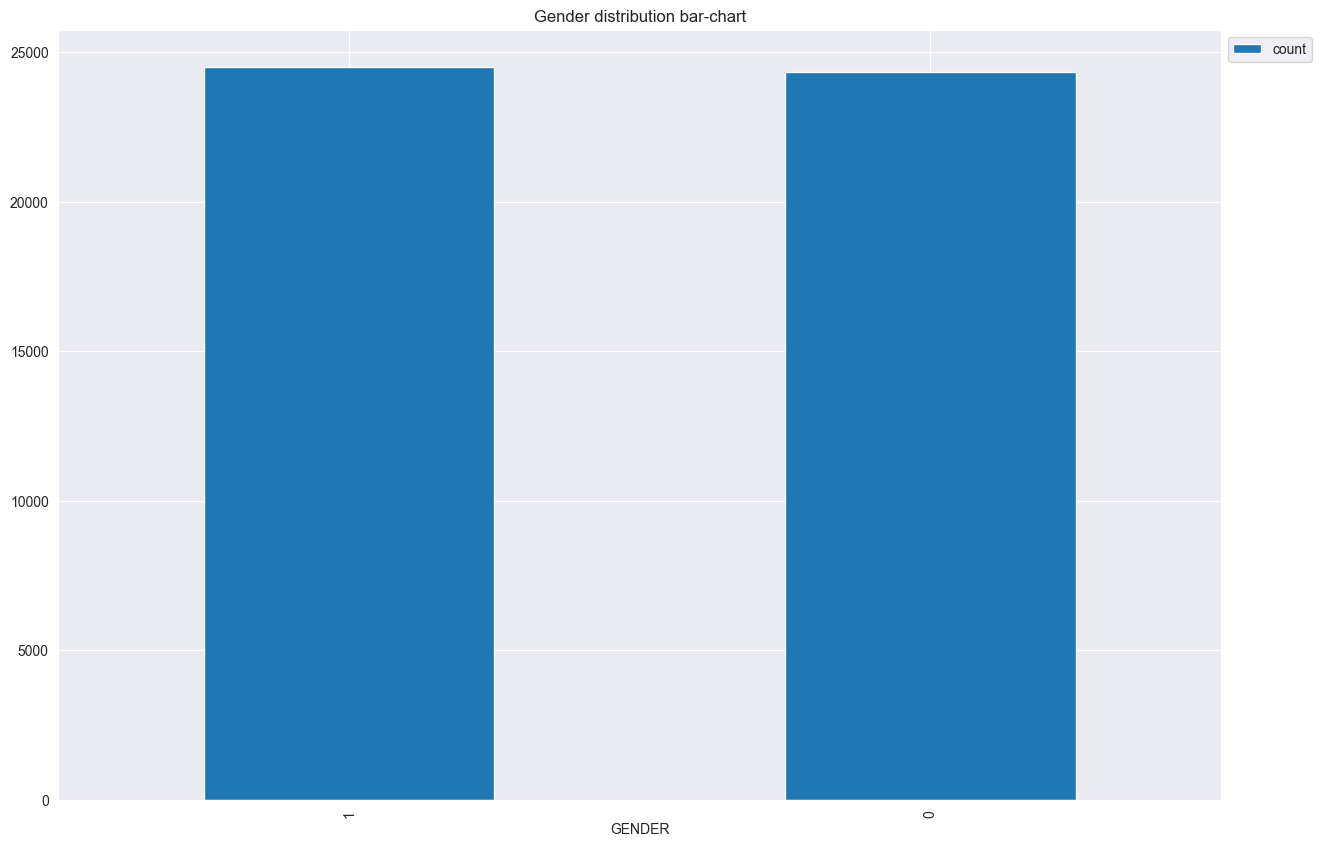

In [6]:
GenderPlot1 = df_unique['GENDER'].value_counts().plot(kind = 'bar',title = "Gender distribution bar-chart", figsize=(15,10))
GenderPlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

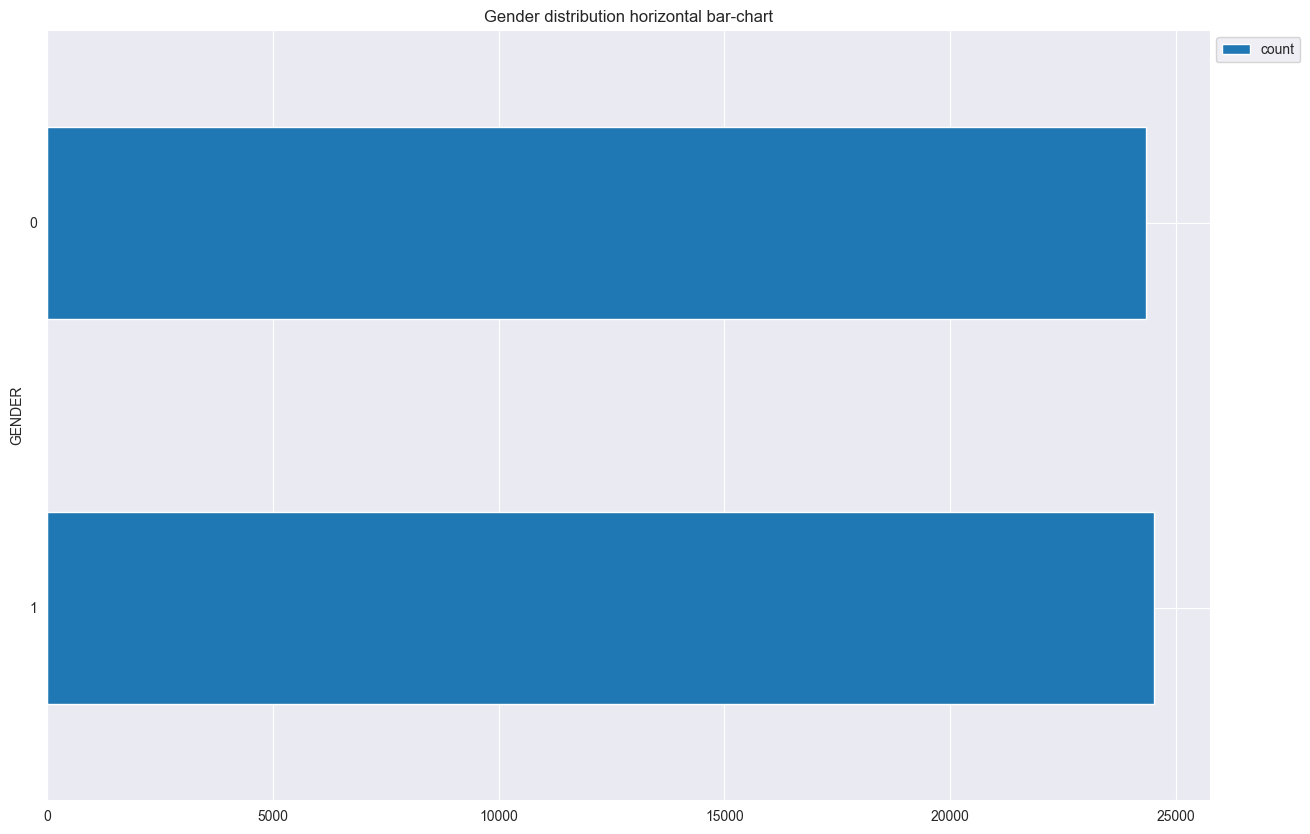

In [7]:
GenderPlot2 = df_unique['GENDER'].value_counts().plot(kind = 'barh',title = "Gender distribution horizontal bar-chart", figsize=(15,10))
GenderPlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

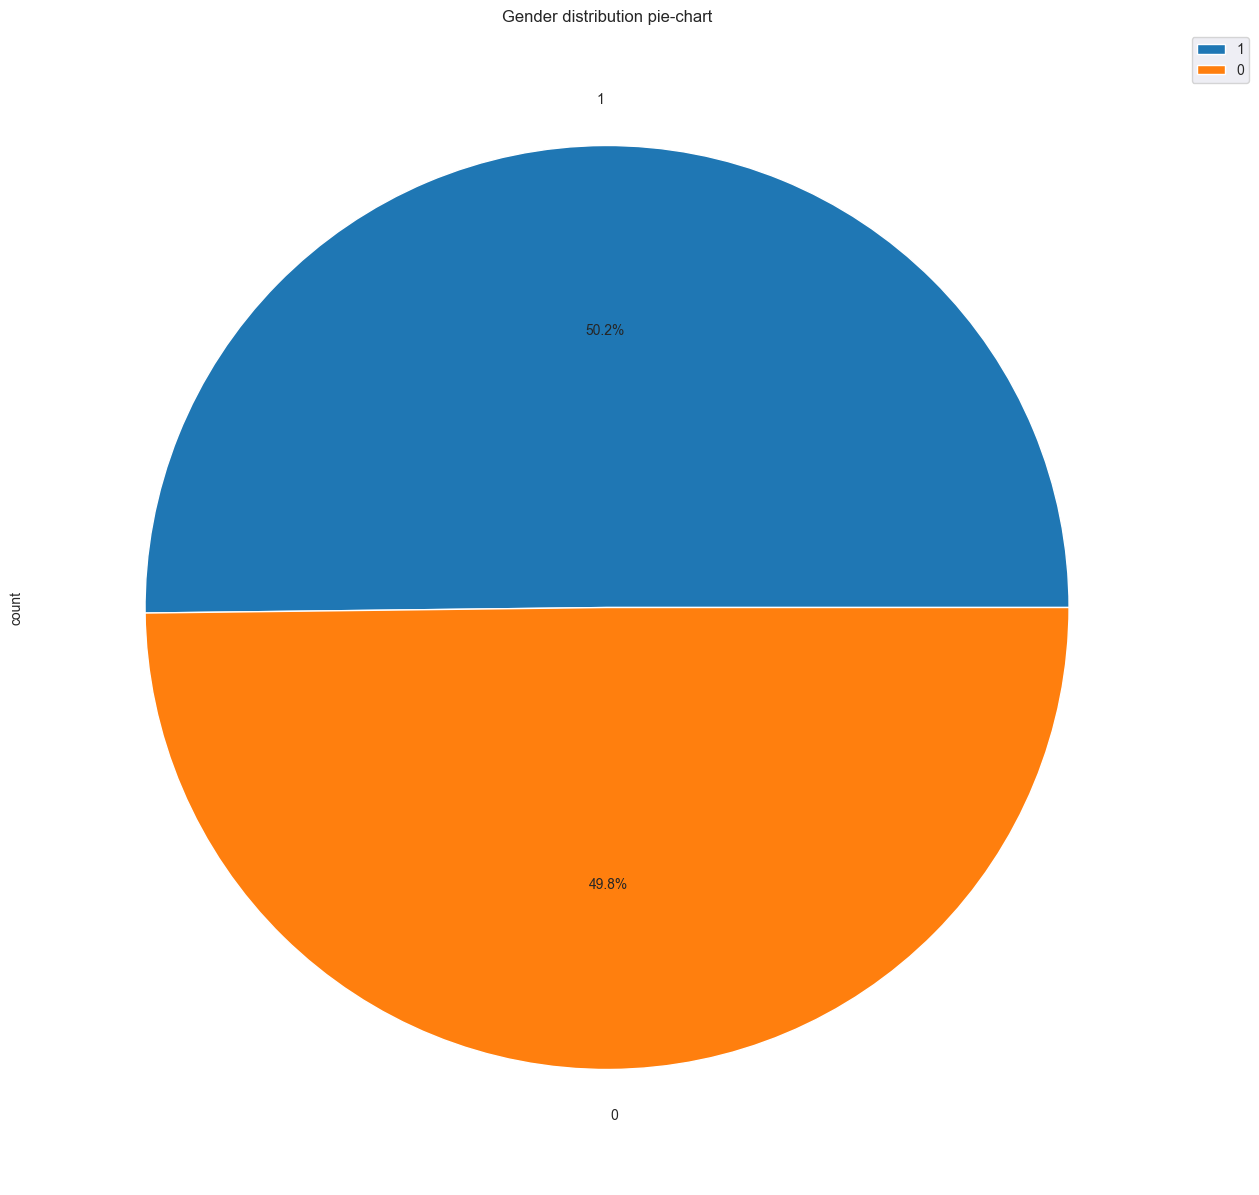

In [8]:
GenderPlot3 = df_unique['GENDER'].value_counts().plot(kind = 'pie',title = "Gender distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
GenderPlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

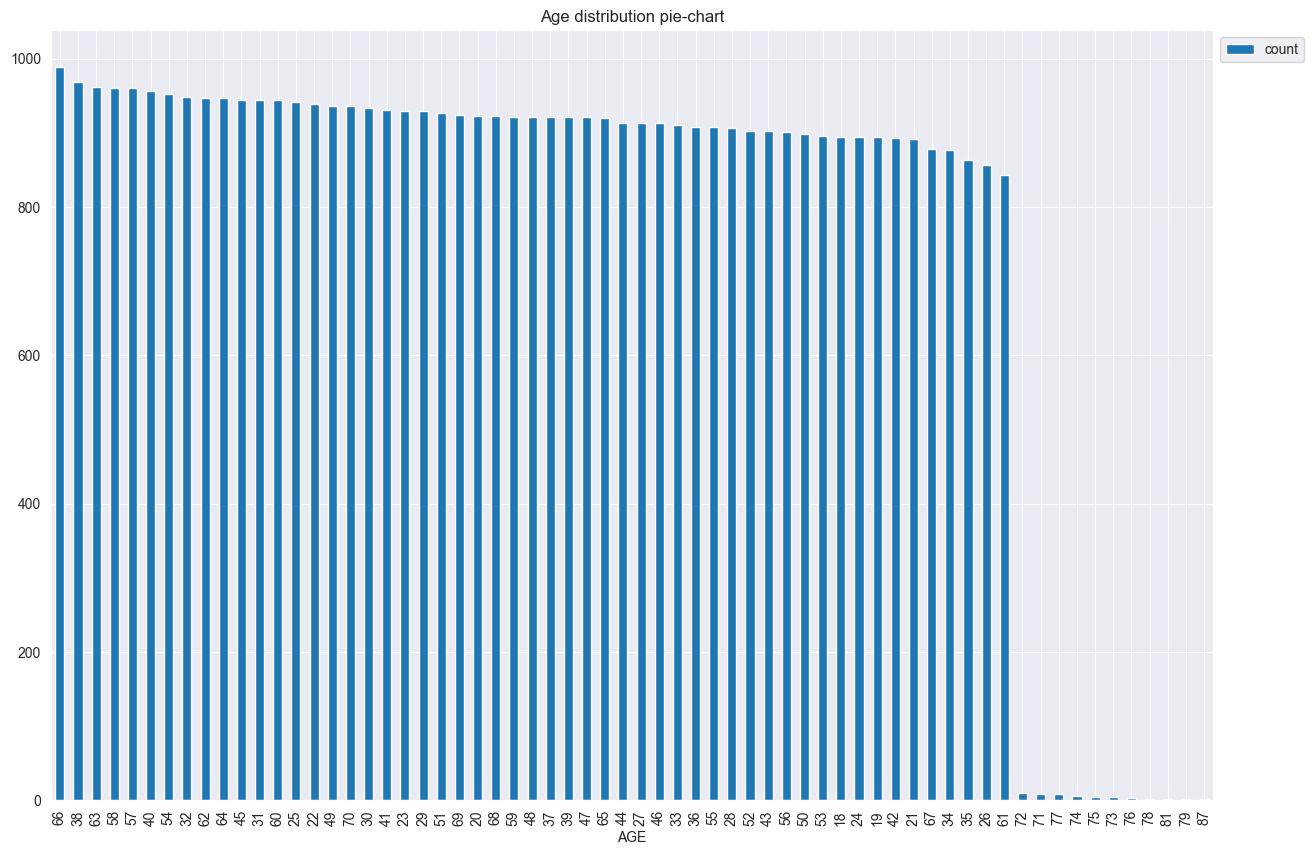

In [9]:
agePlot1 = df_unique['AGE'].value_counts().plot(kind = 'bar',title = "Age distribution pie-chart", figsize=(15,10), legend = True)
agePlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

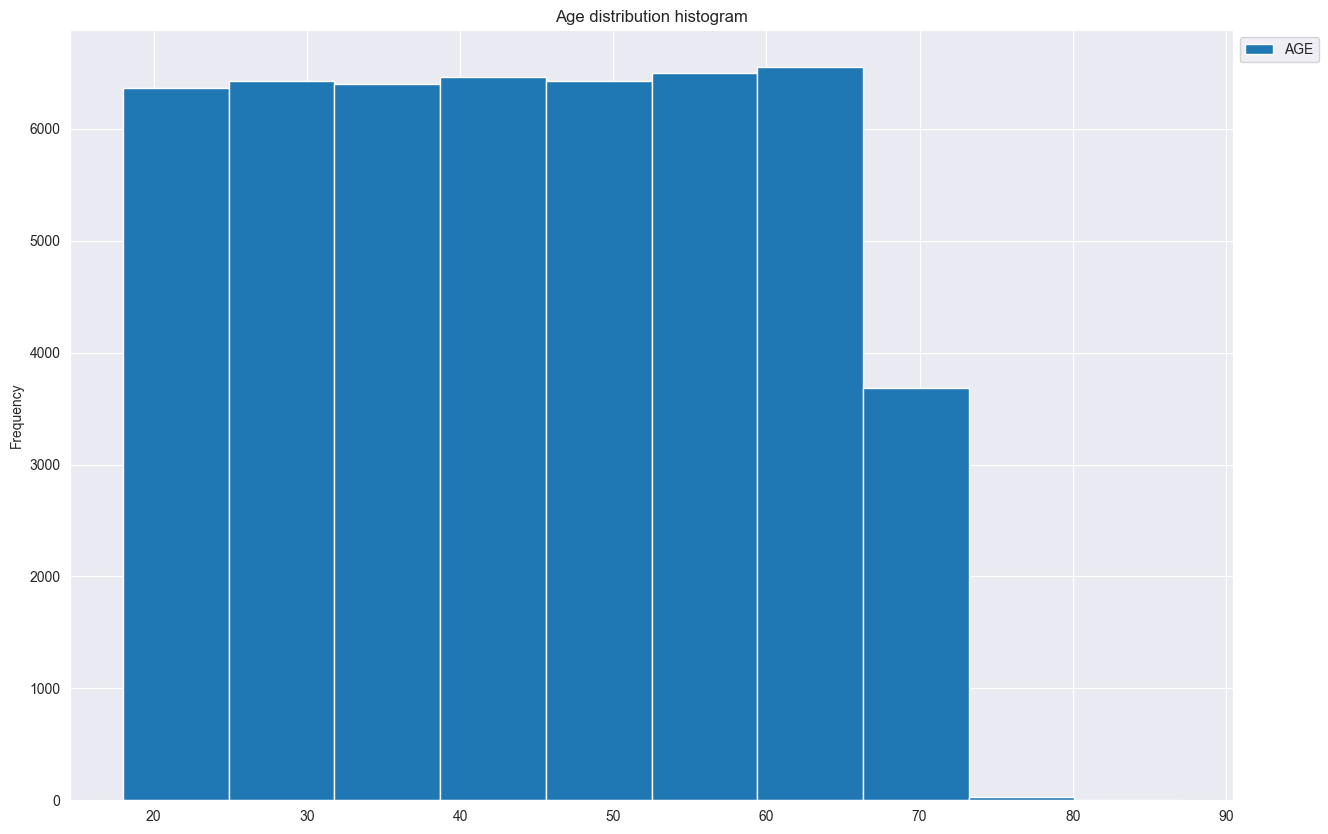

In [10]:
agePlot2 = df_unique['AGE'].plot(kind = 'hist',title = "Age distribution histogram", figsize=(15,10), legend = True, bins=10)
agePlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

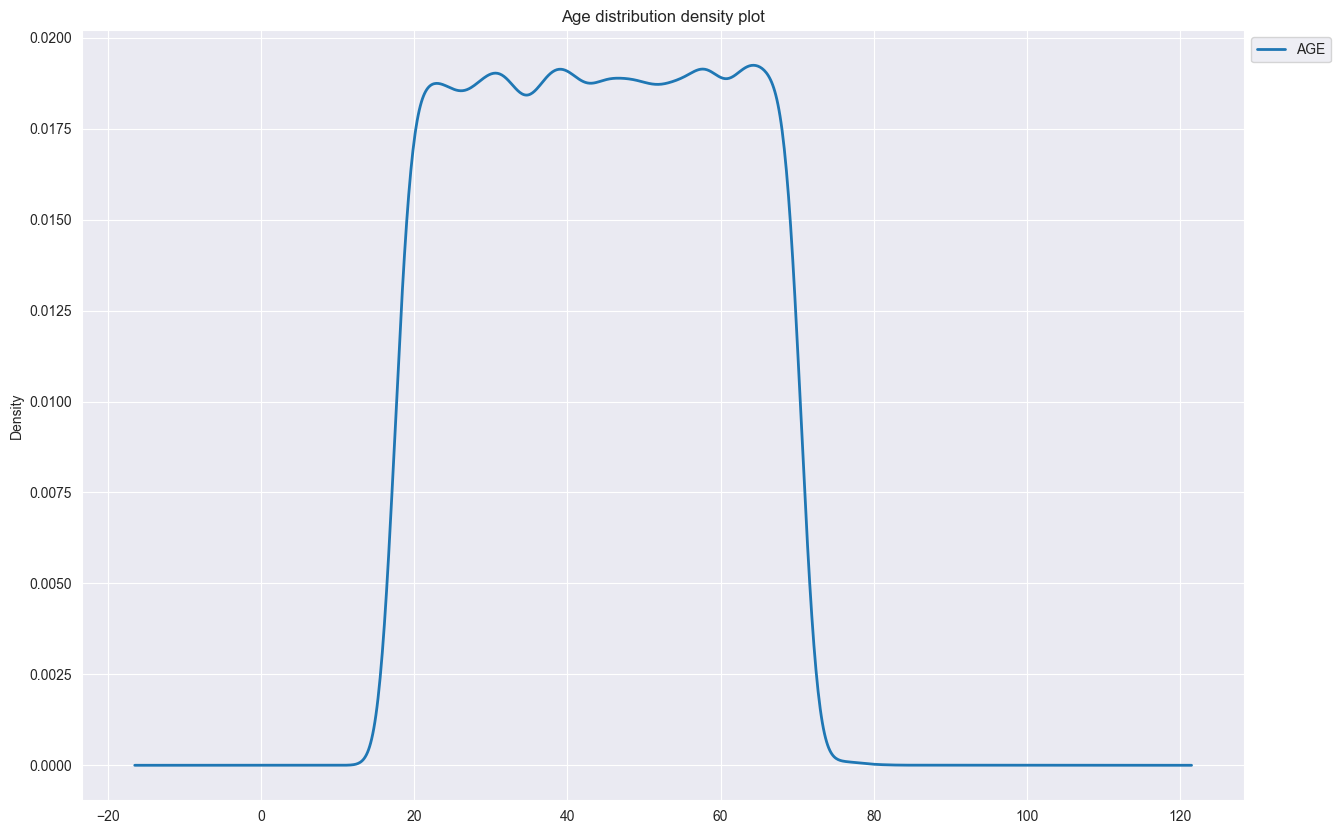

In [11]:
agePlot3 = df_unique['AGE'].plot(kind = 'kde',title = "Age distribution density plot", figsize=(15,10), legend = True, linewidth=2)
agePlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

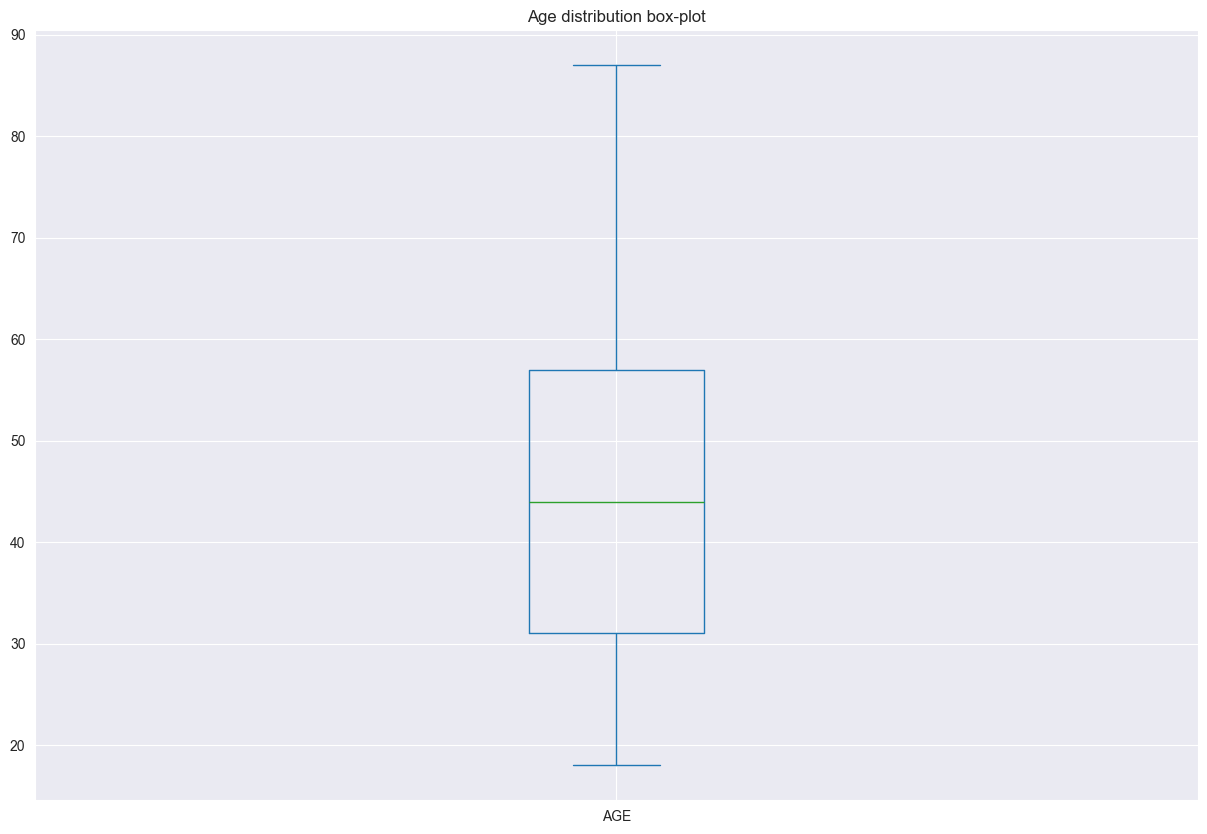

In [12]:
agePlot4 = df_unique['AGE'].plot(kind = 'box',title = "Age distribution box-plot", figsize=(15,10))

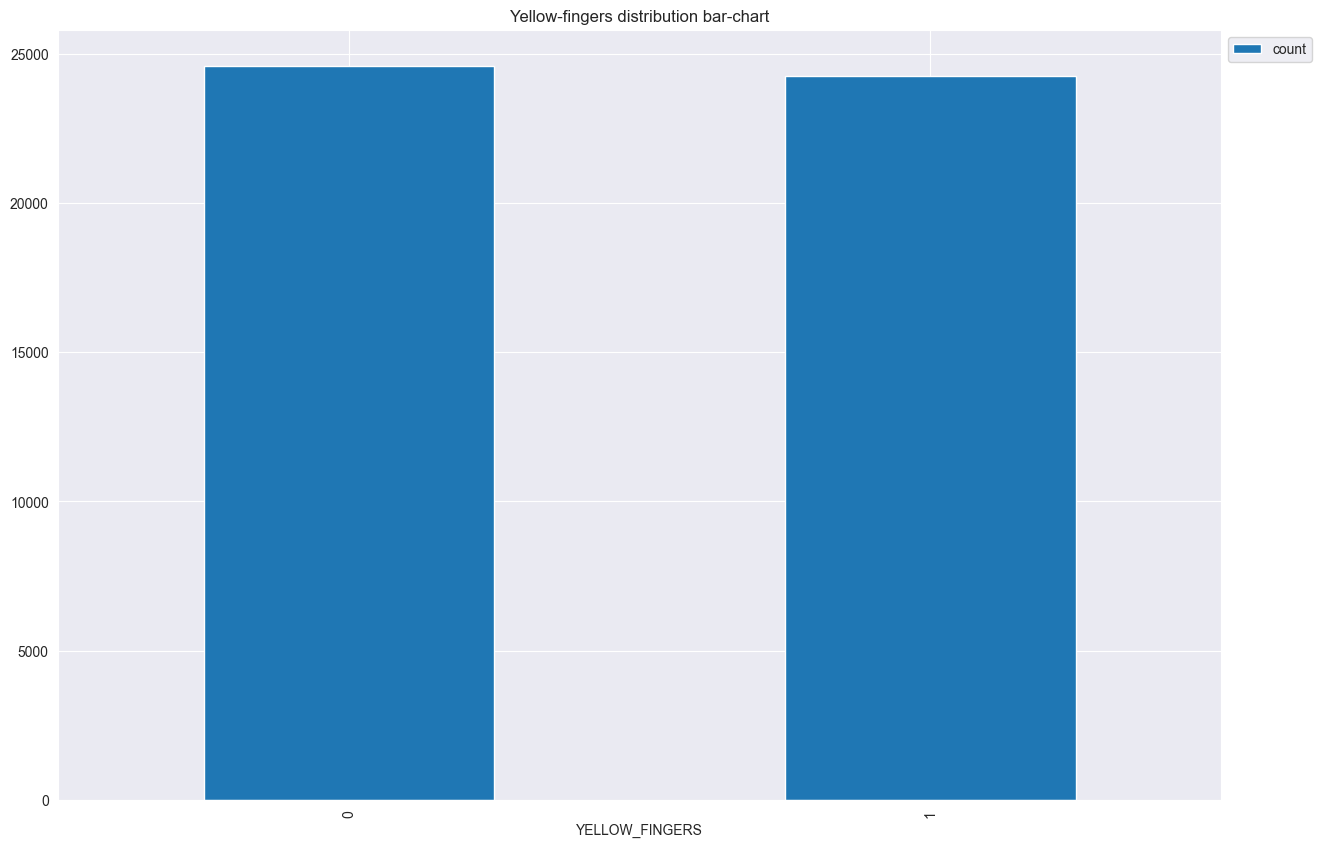

In [13]:
yFingerPlot1 = df_unique['YELLOW_FINGERS'].value_counts().plot(kind = 'bar',title = "Yellow-fingers distribution bar-chart", figsize=(15,10))
yFingerPlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

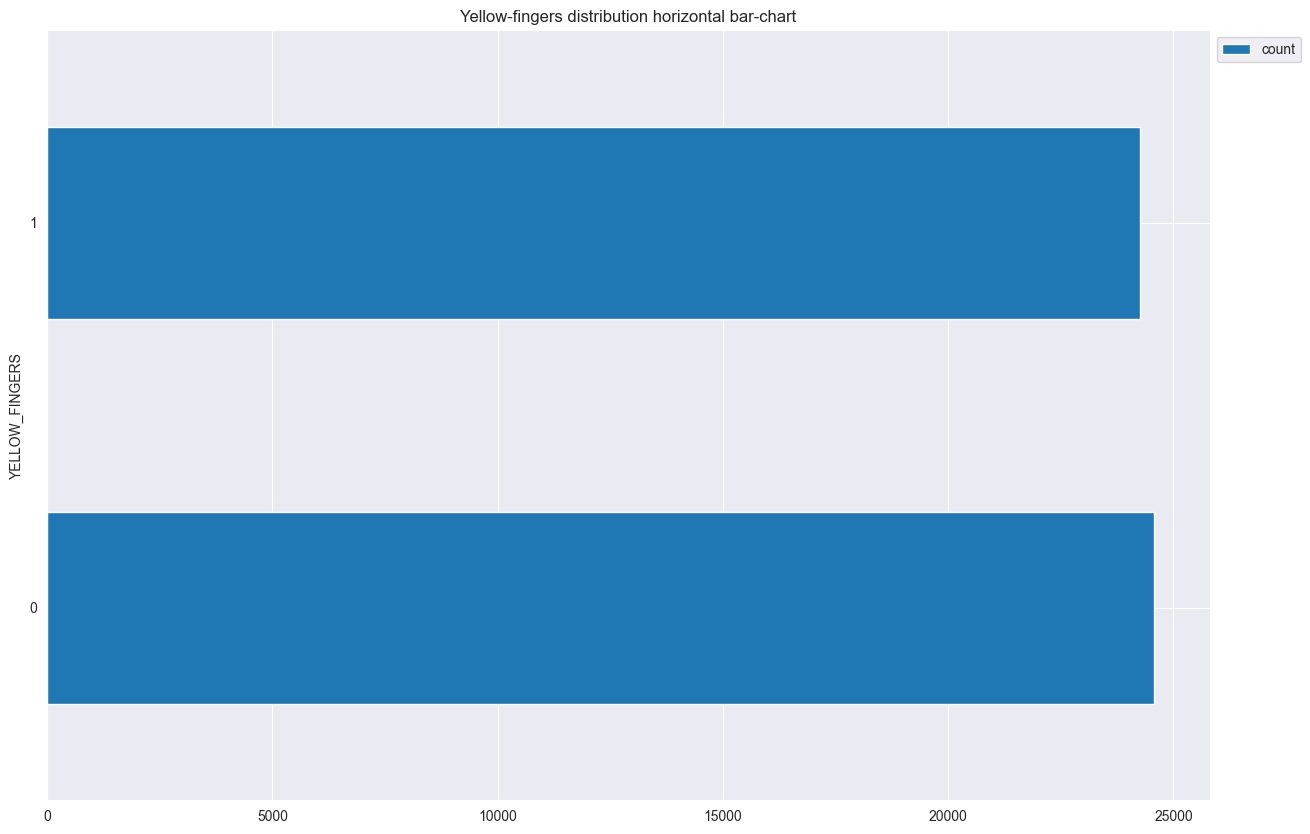

In [14]:
yFingerPlot2 = df_unique['YELLOW_FINGERS'].value_counts().plot(kind = 'barh',title = "Yellow-fingers distribution horizontal bar-chart", figsize=(15,10))
yFingerPlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

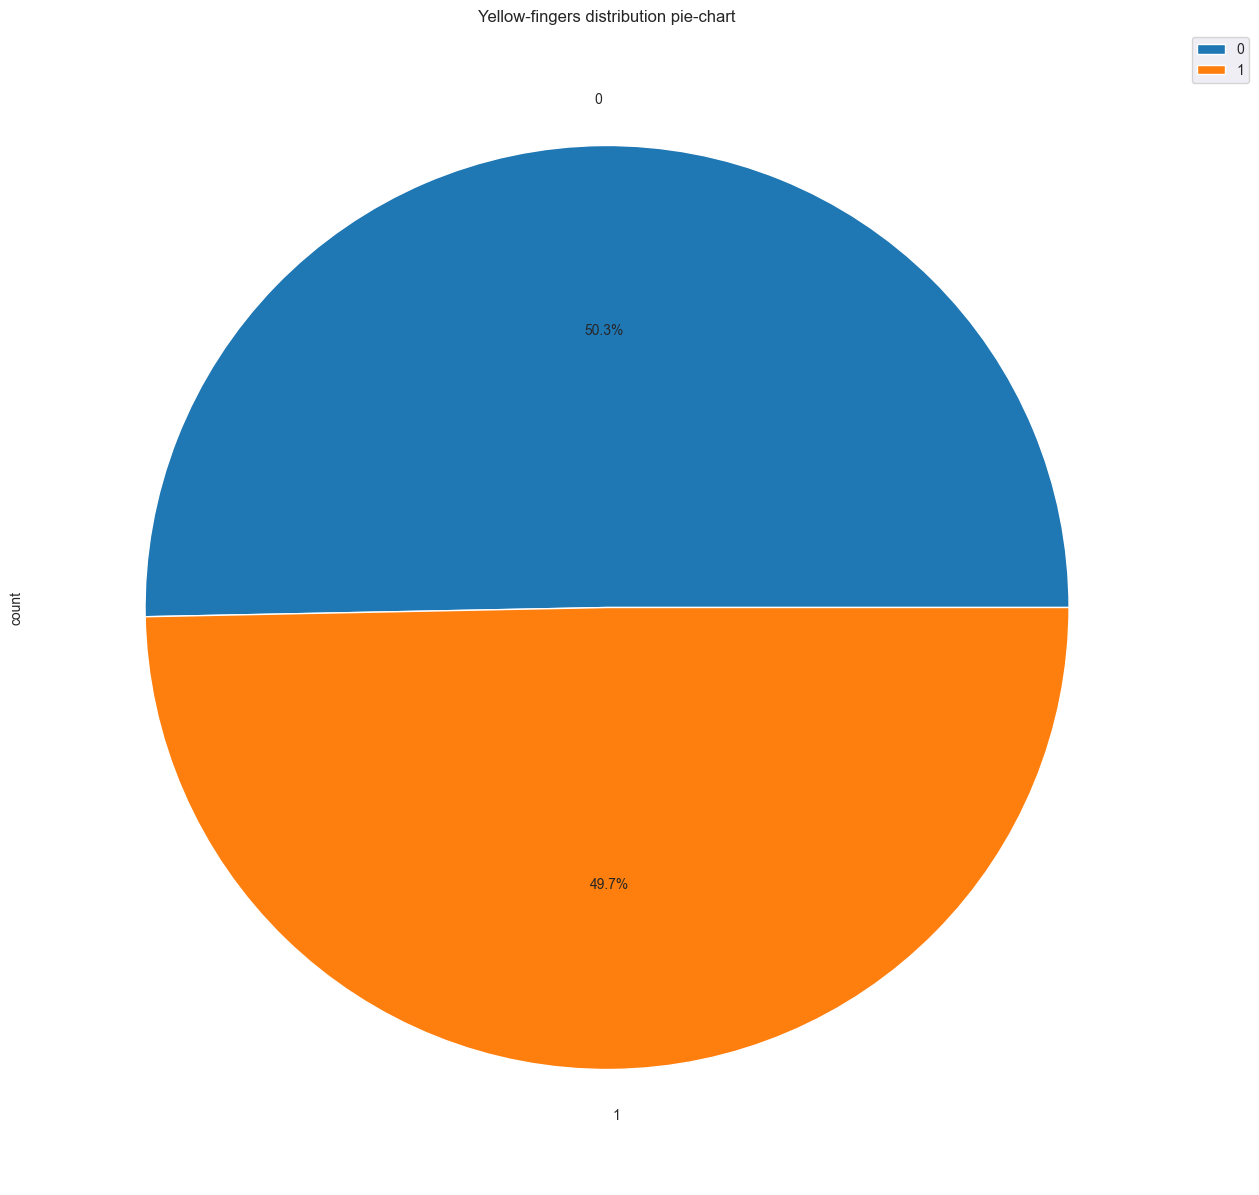

In [15]:
yFingerPlot3 = df_unique['YELLOW_FINGERS'].value_counts().plot(kind = 'pie',title = "Yellow-fingers distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
yFingerPlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

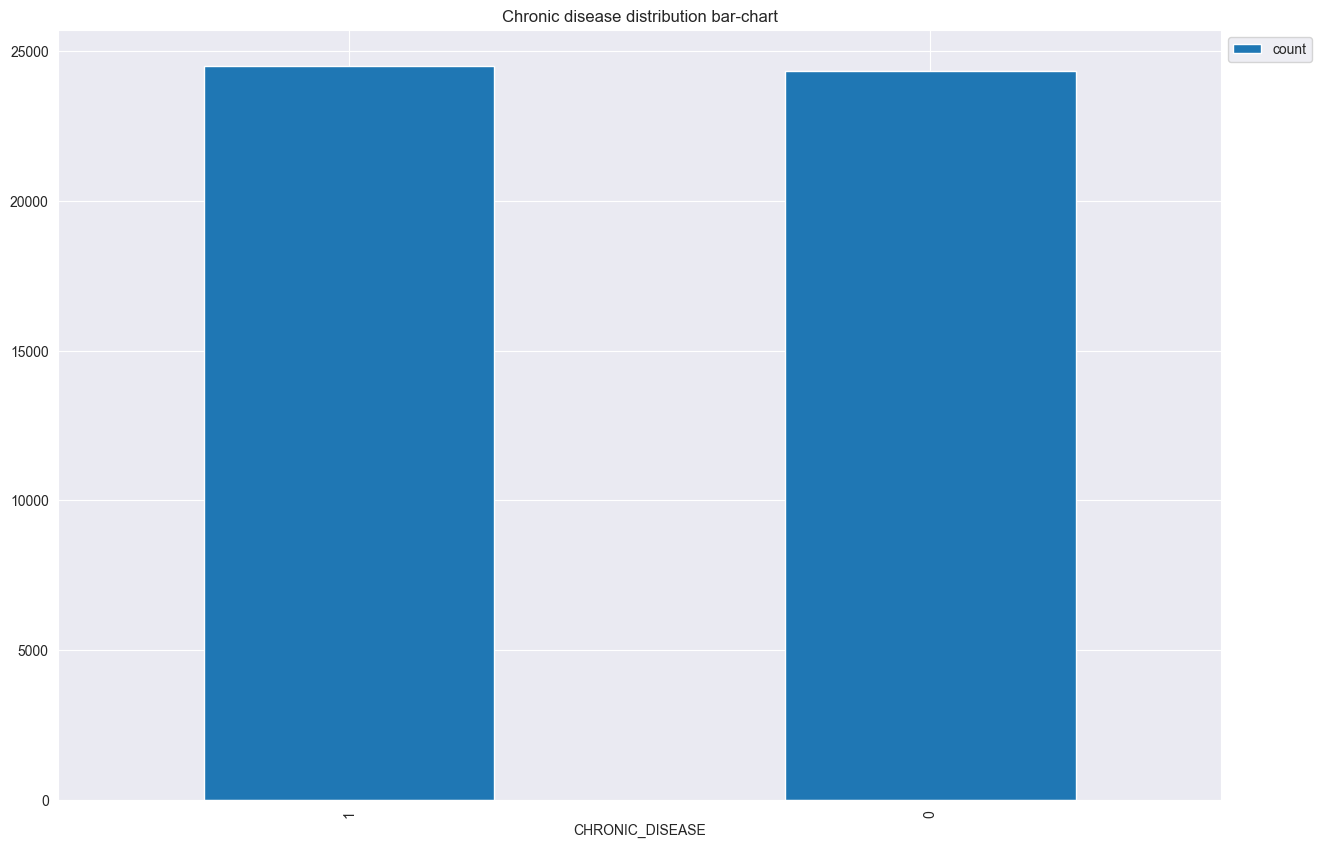

In [16]:
cDiseasePlot1 = df_unique['CHRONIC_DISEASE'].value_counts().plot(kind = 'bar',title = "Chronic disease distribution bar-chart", figsize=(15,10))
cDiseasePlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

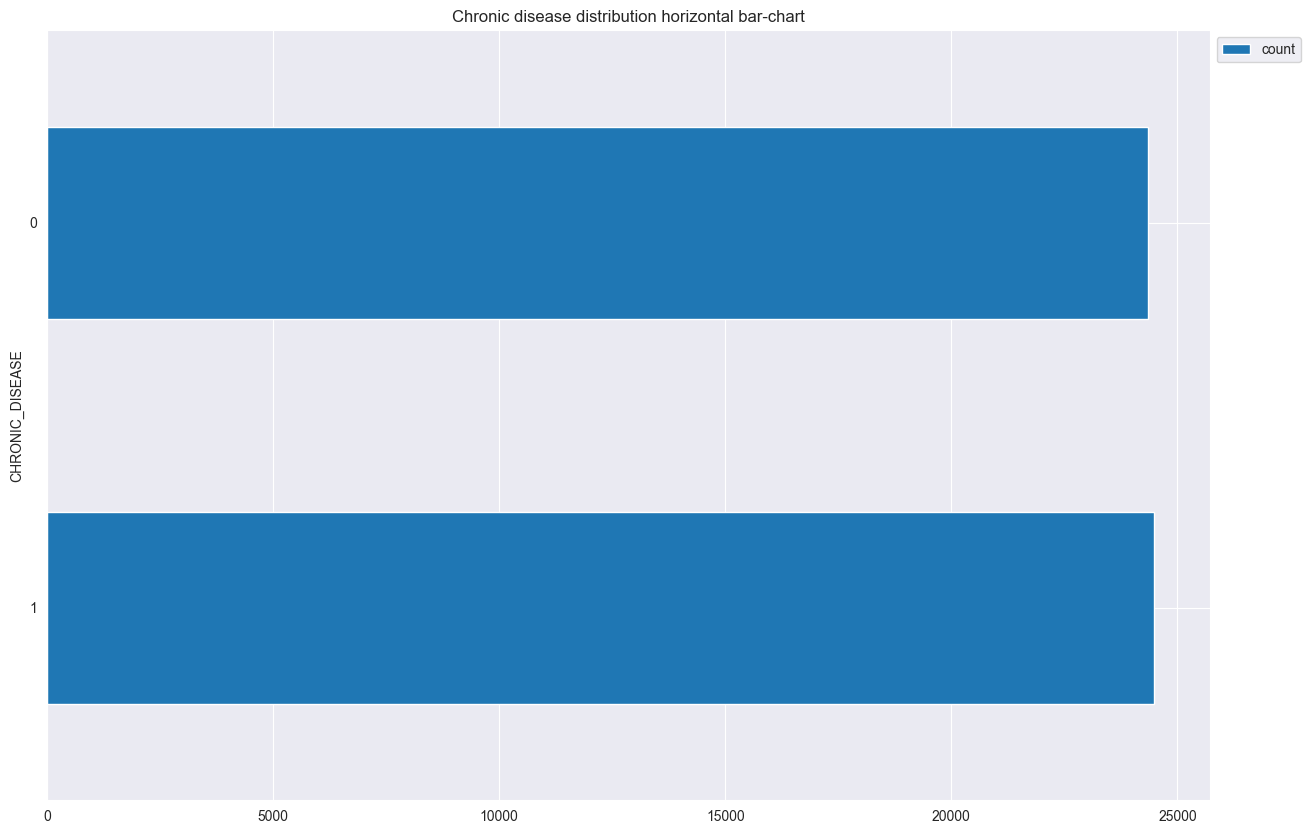

In [17]:
cDiseasePlot2 = df_unique['CHRONIC_DISEASE'].value_counts().plot(kind = 'barh',title = "Chronic disease distribution horizontal bar-chart", figsize=(15,10))
cDiseasePlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

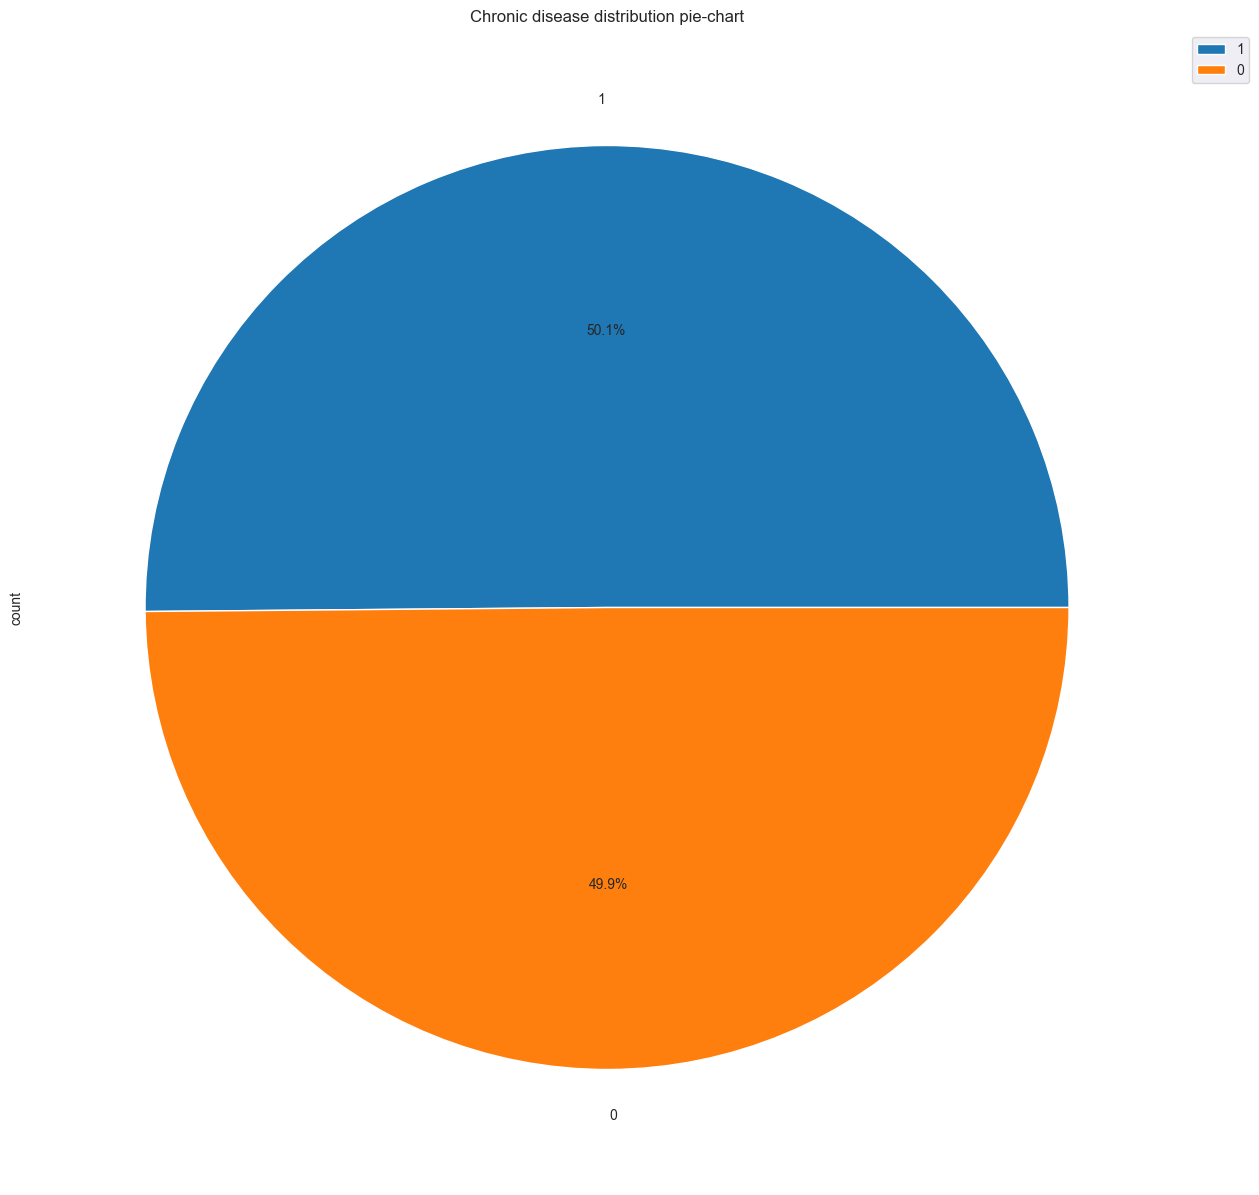

In [18]:
cDiseasePlot3 = df_unique['CHRONIC_DISEASE'].value_counts().plot(kind = 'pie',title = "Chronic disease distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
cDiseasePlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

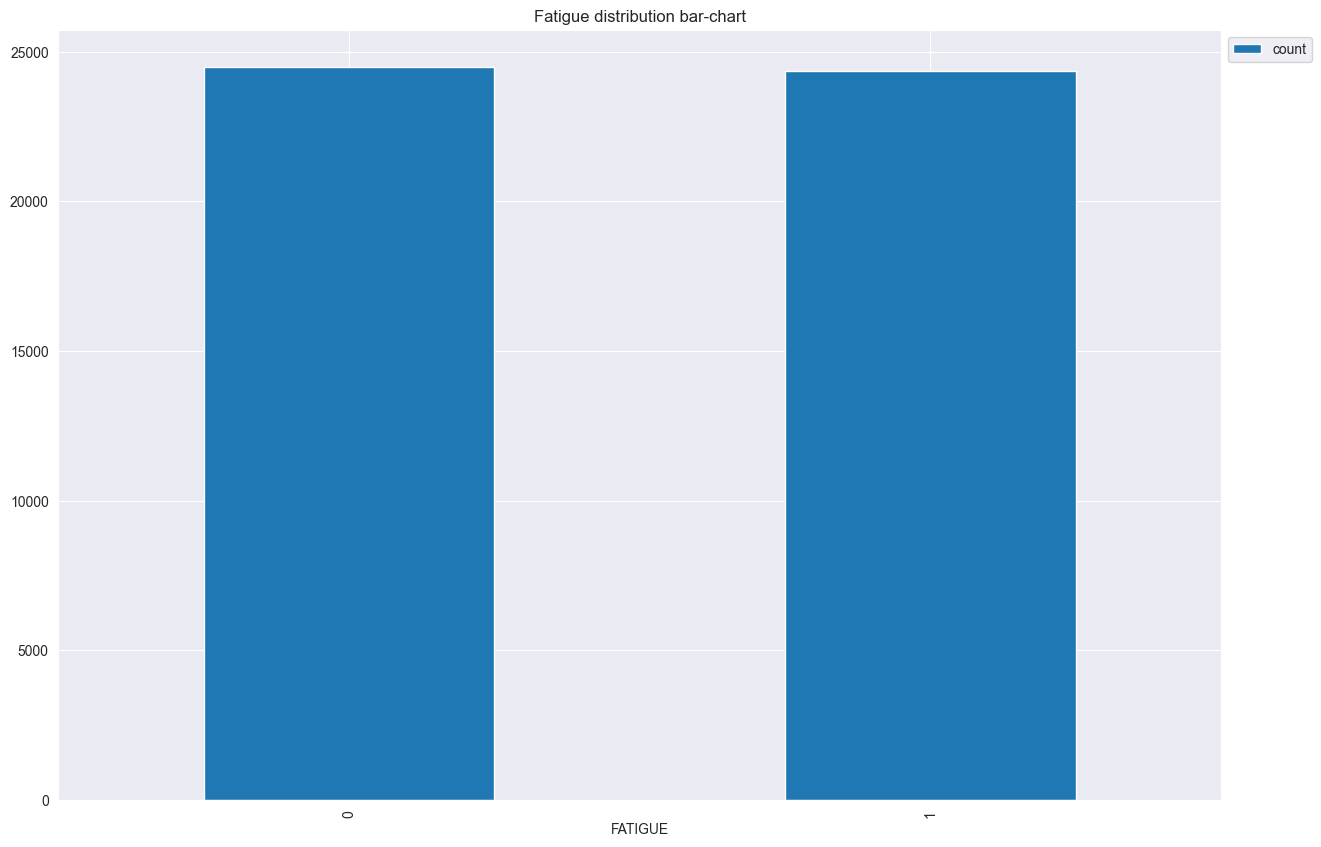

In [19]:
fatiguePlot1 = df_unique['FATIGUE'].value_counts().plot(kind = 'bar',title = "Fatigue distribution bar-chart", figsize=(15,10))
fatiguePlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

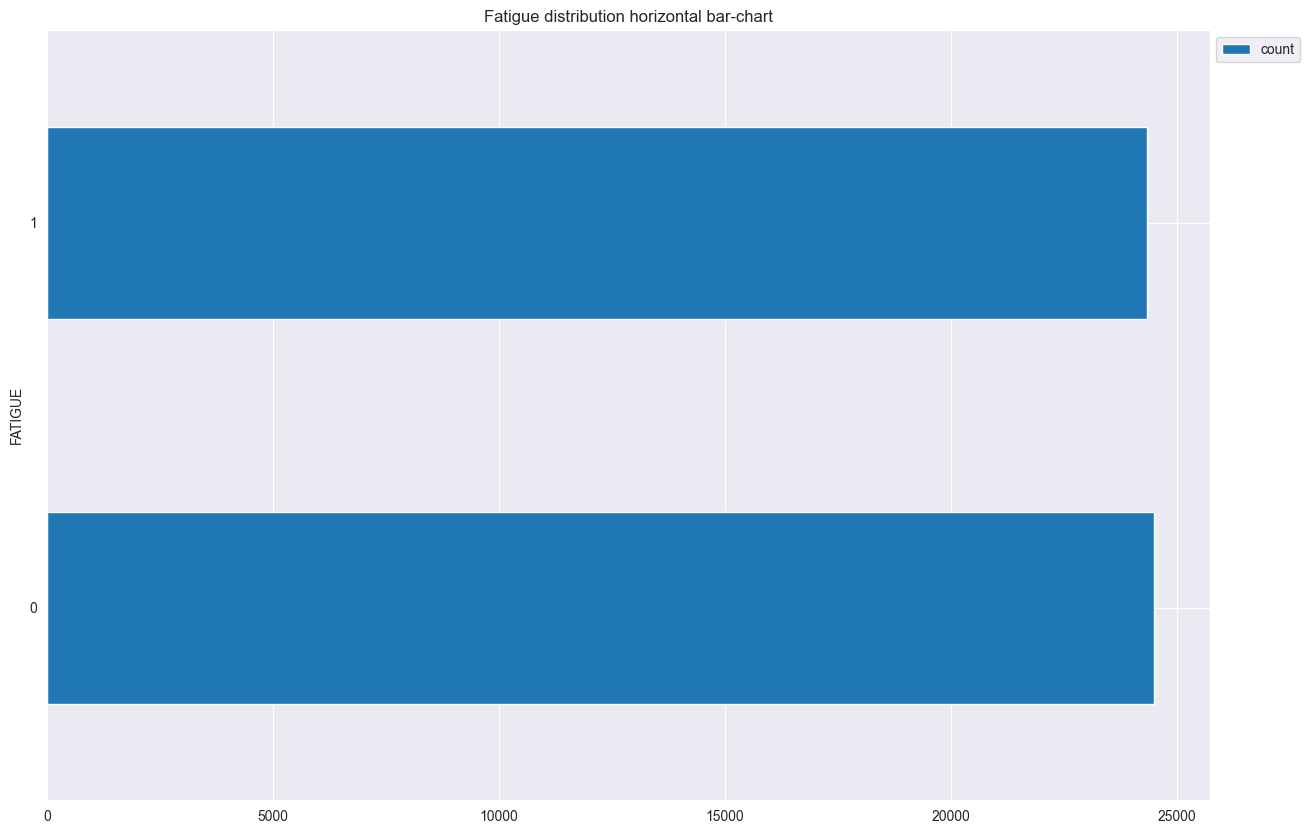

In [20]:
fatiguePlot2 = df_unique['FATIGUE'].value_counts().plot(kind = 'barh',title = "Fatigue distribution horizontal bar-chart", figsize=(15,10))
fatiguePlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

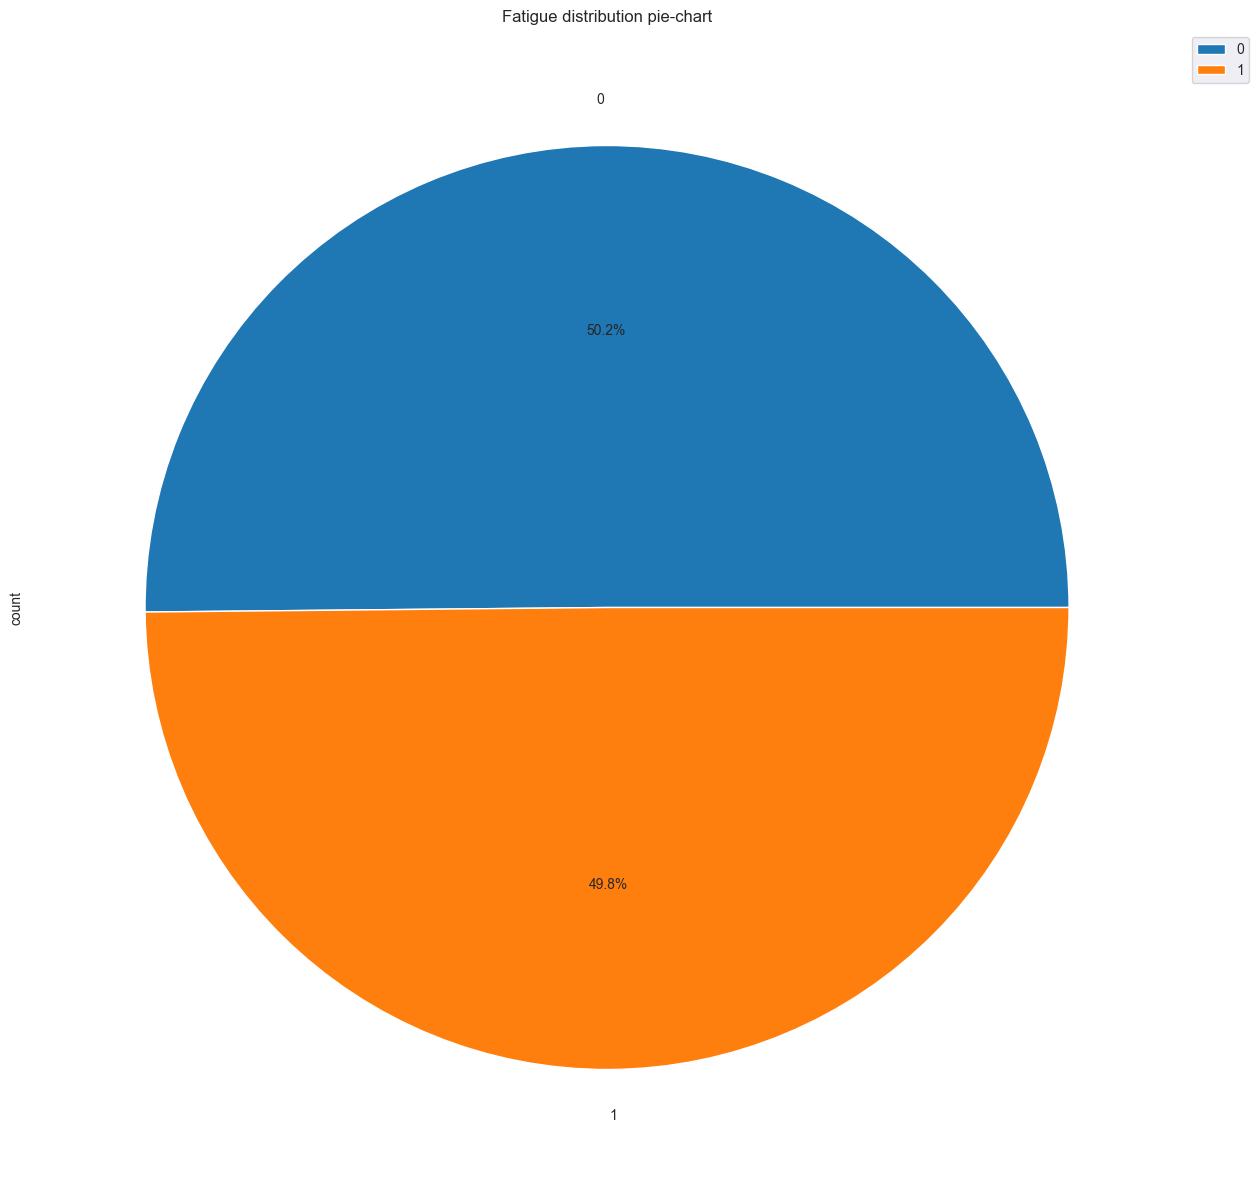

In [21]:
fatiguePlot3 = df_unique['FATIGUE'].value_counts().plot(kind = 'pie',title = "Fatigue distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
fatiguePlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

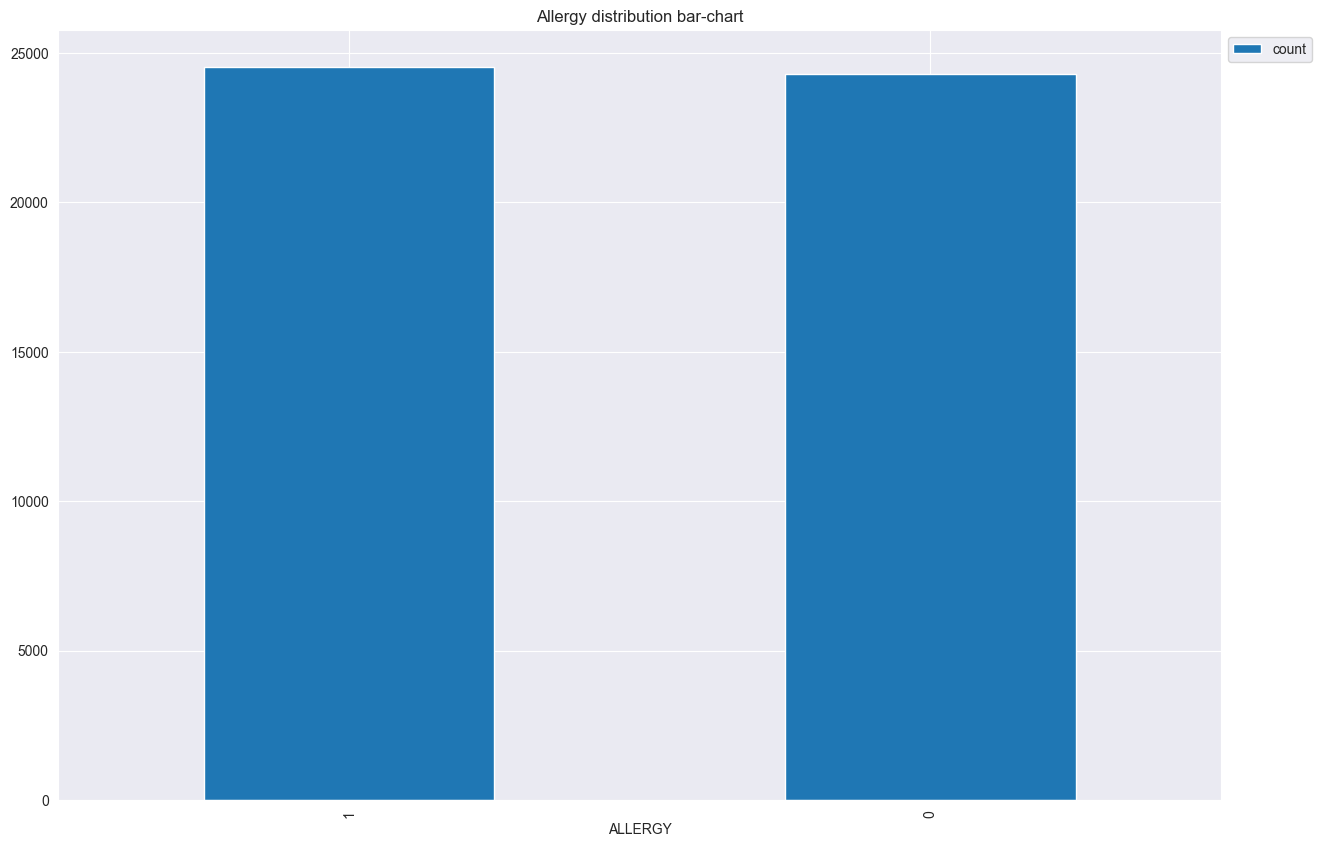

In [22]:
allergyPlot1 = df_unique['ALLERGY'].value_counts().plot(kind = 'bar',title = "Allergy distribution bar-chart", figsize=(15,10))
allergyPlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

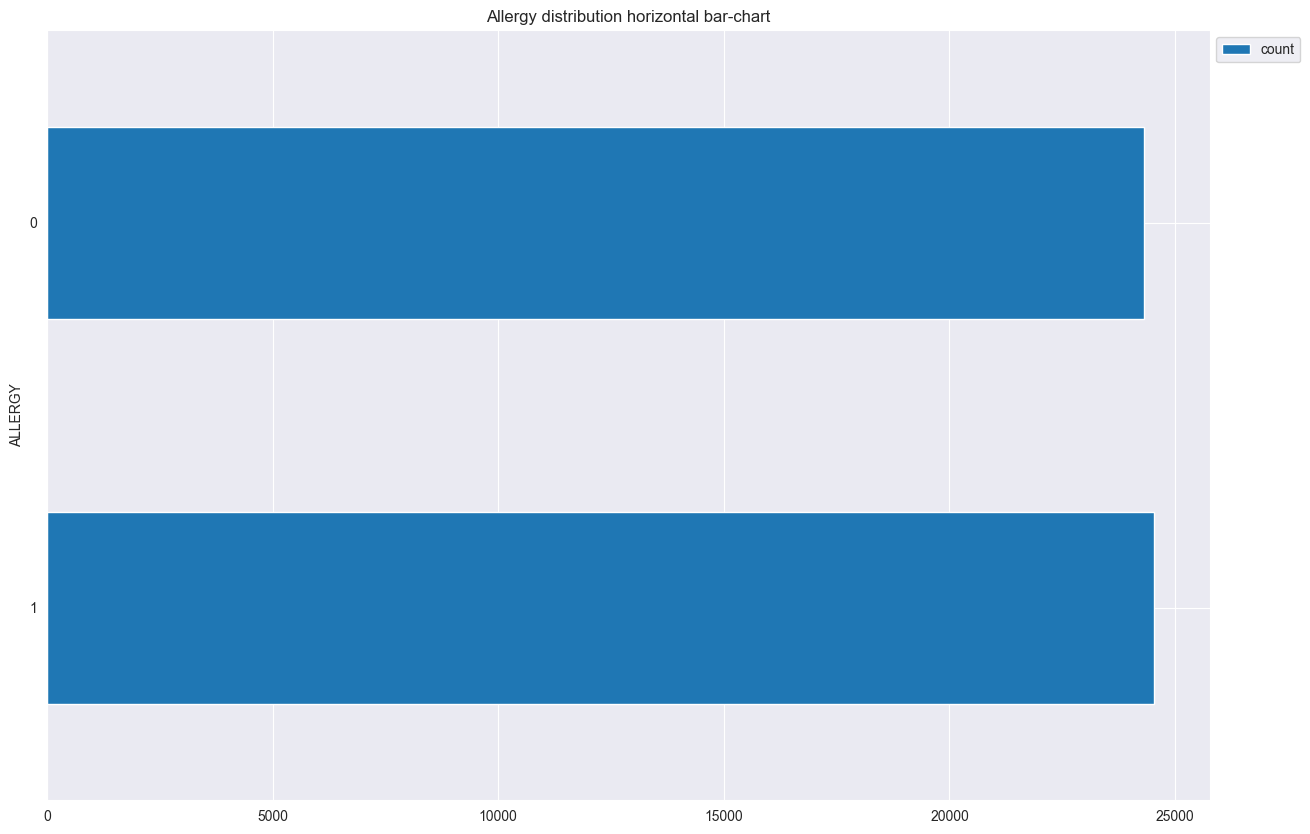

In [23]:
allergyPlot2 = df_unique['ALLERGY'].value_counts().plot(kind = 'barh',title = "Allergy distribution horizontal bar-chart", figsize=(15,10))
allergyPlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

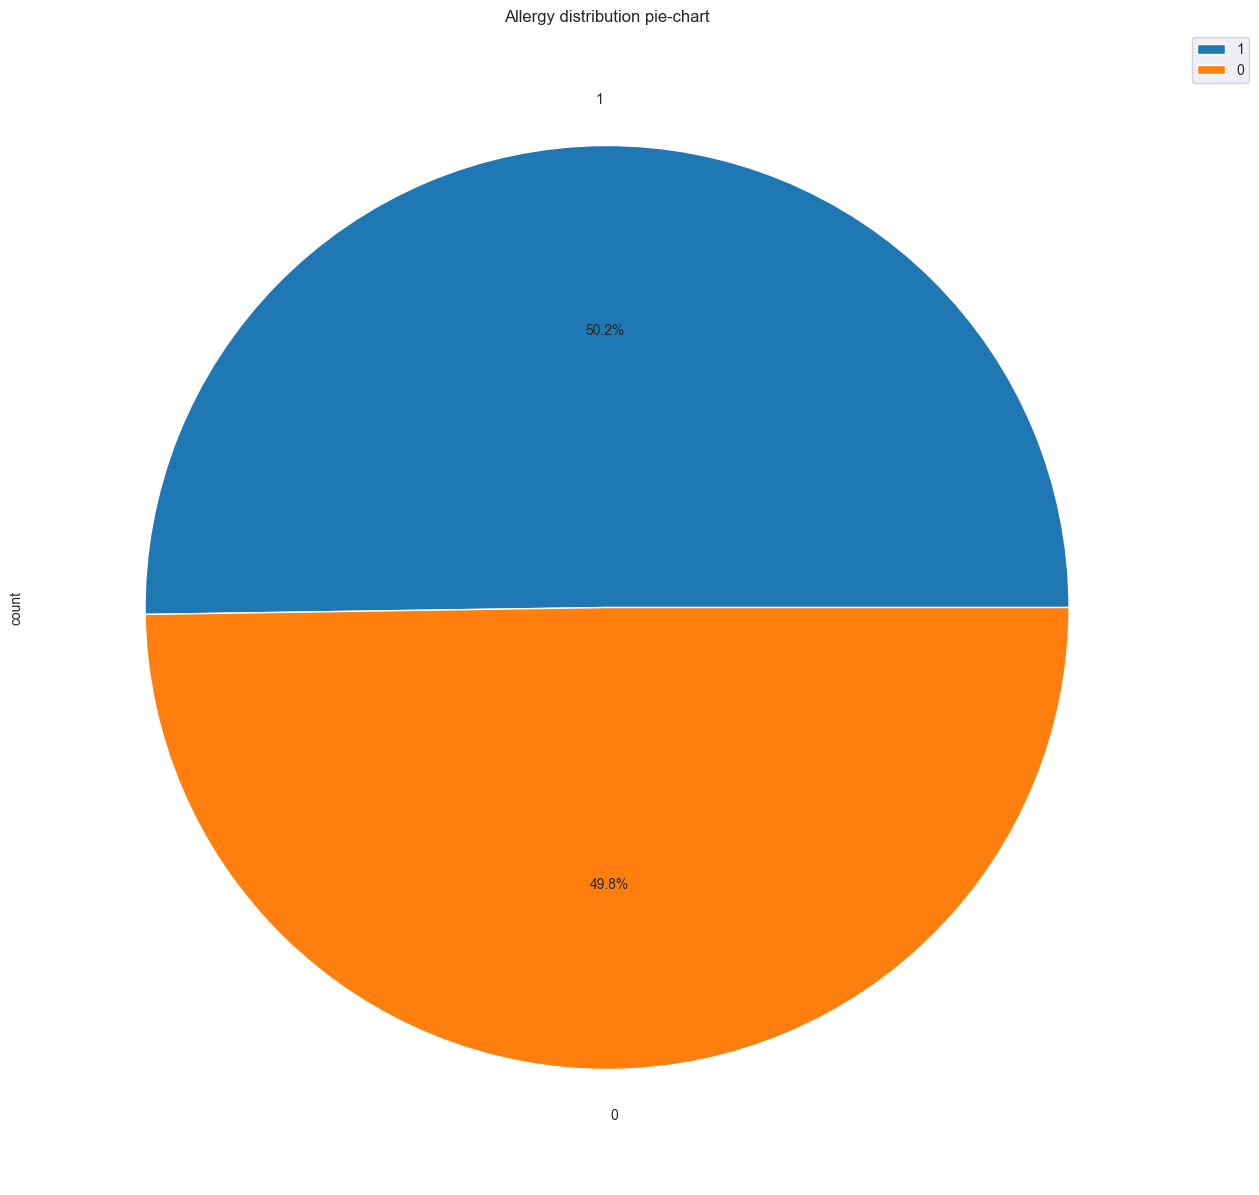

In [24]:
allergyPlot3 = df_unique['ALLERGY'].value_counts().plot(kind = 'pie',title = "Allergy distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
allergyPlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

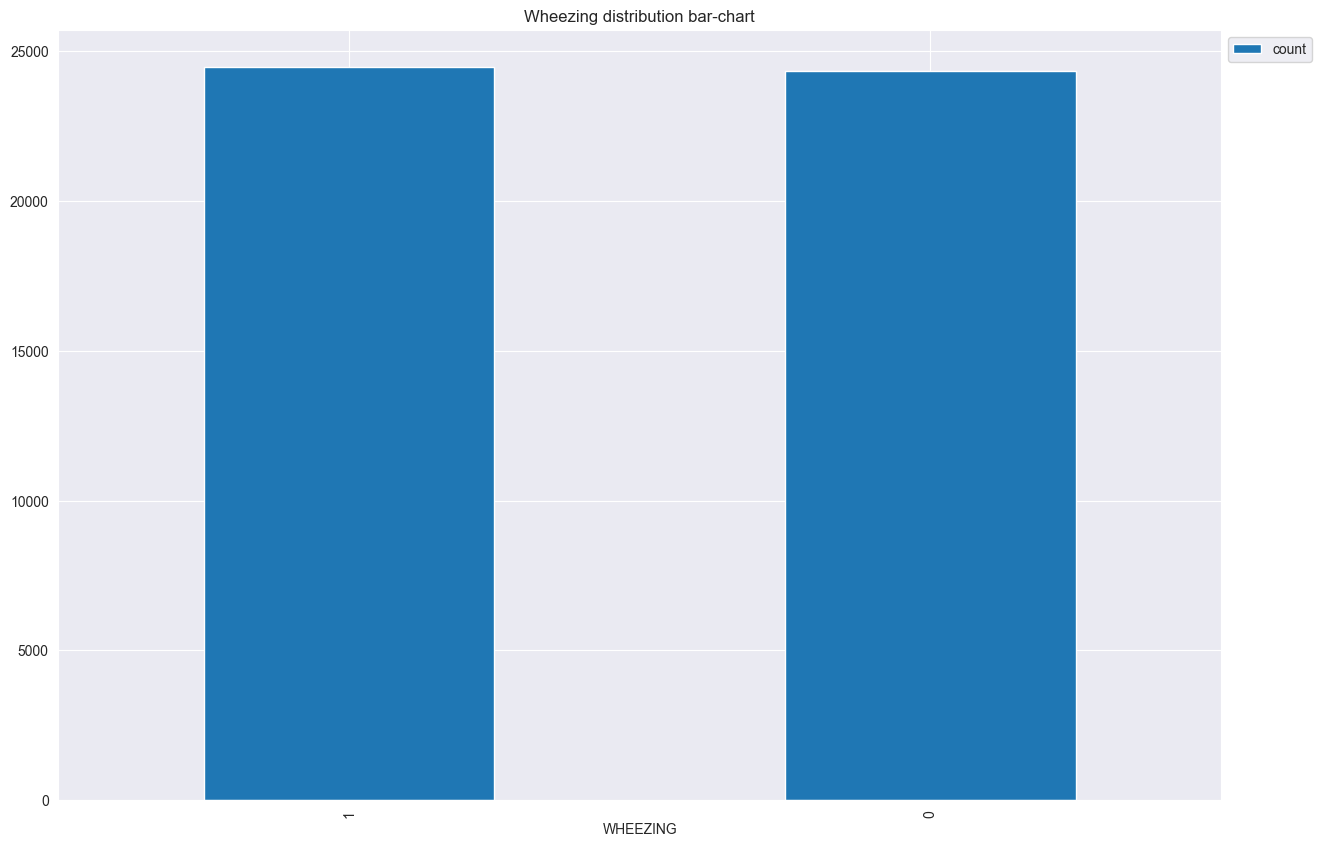

In [25]:
wheezingPlot1 = df_unique['WHEEZING'].value_counts().plot(kind = 'bar',title = "Wheezing distribution bar-chart", figsize=(15,10))
wheezingPlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

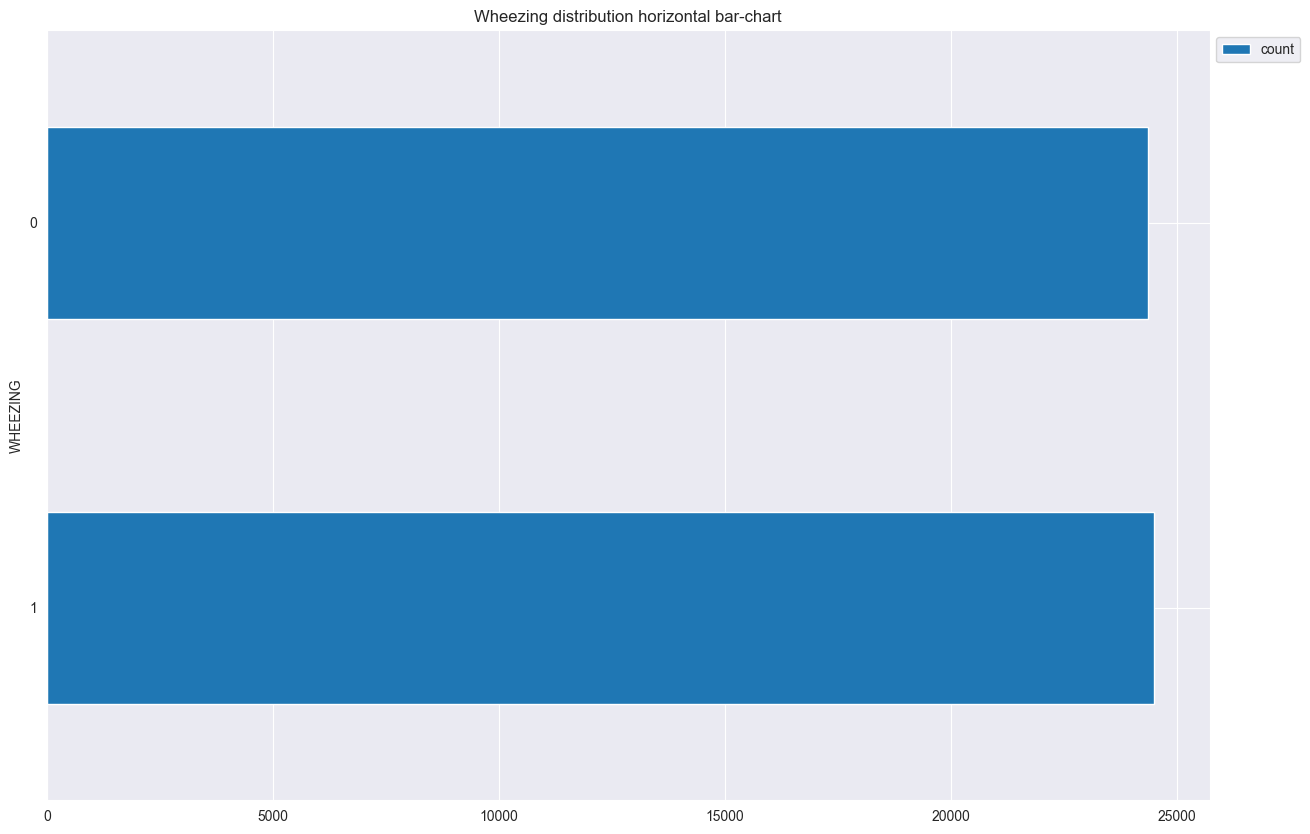

In [26]:
wheezingPlot2 = df_unique['WHEEZING'].value_counts().plot(kind = 'barh',title = "Wheezing distribution horizontal bar-chart", figsize=(15,10))
wheezingPlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

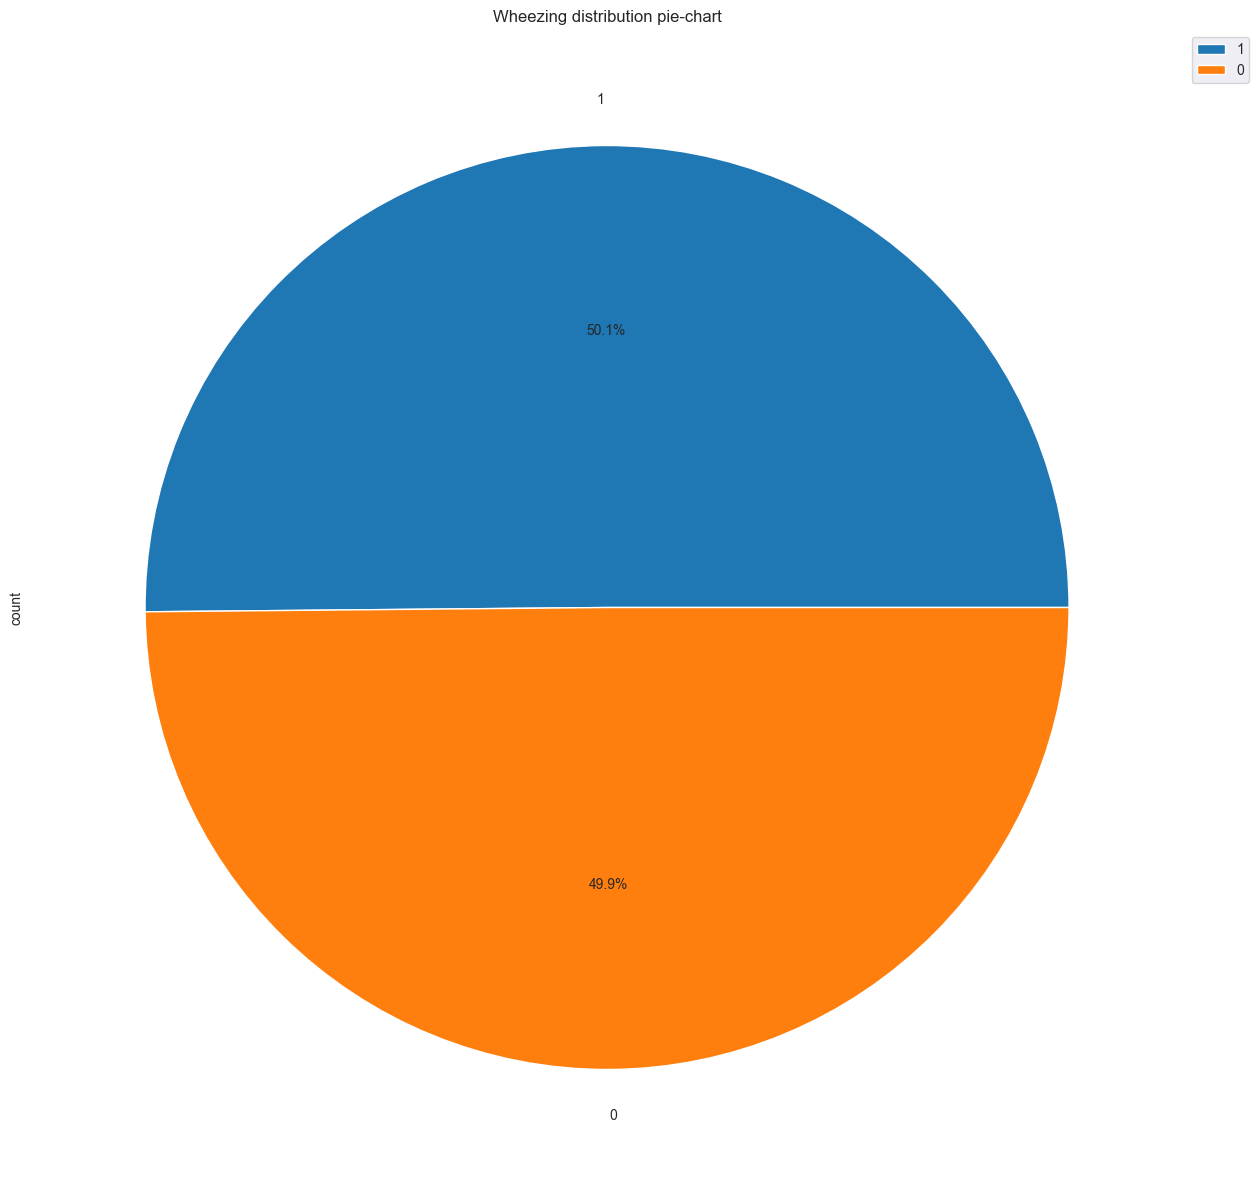

In [27]:
wheezingPlot3 = df_unique['WHEEZING'].value_counts().plot(kind = 'pie',title = "Wheezing distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
wheezingPlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

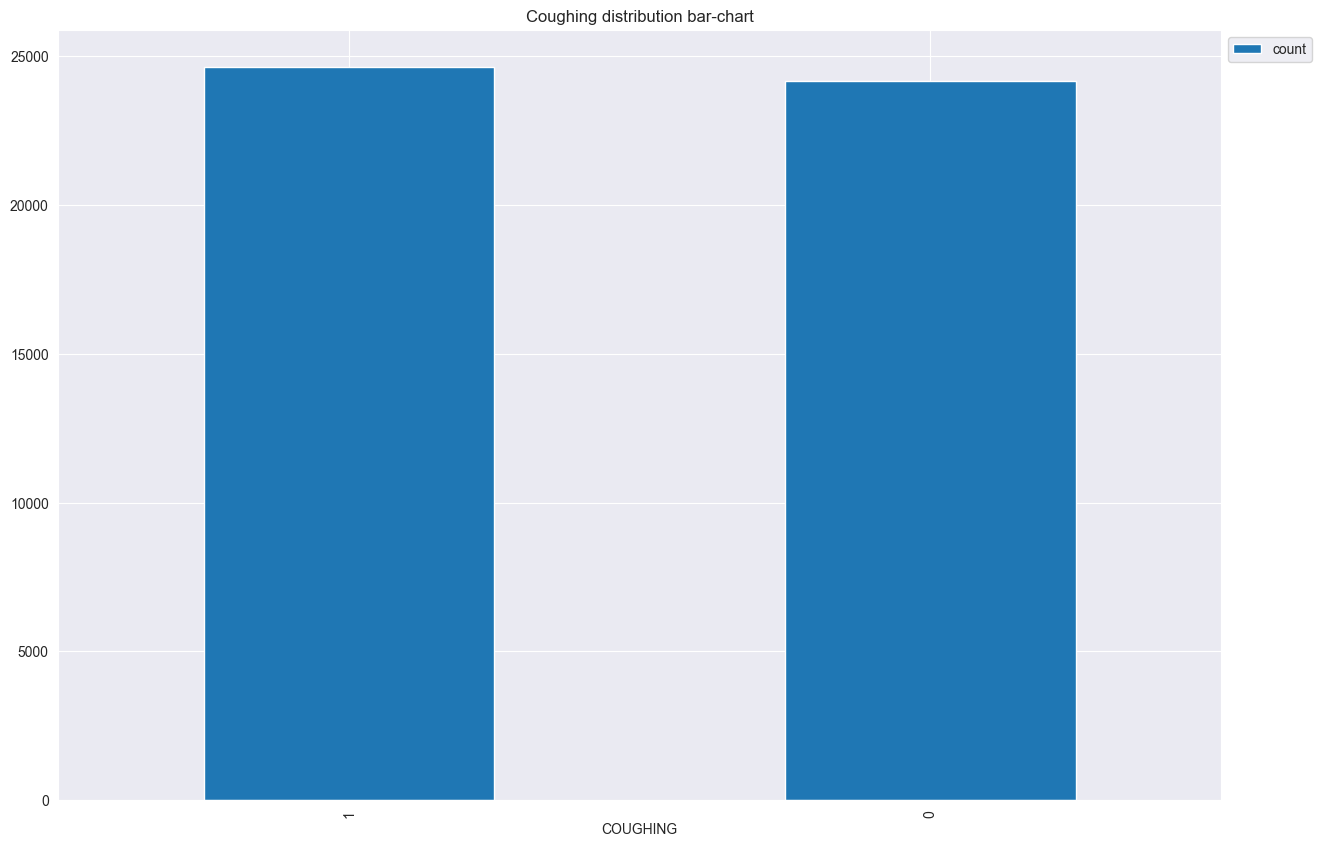

In [28]:
coughingPlot1 = df_unique['COUGHING'].value_counts().plot(kind = 'bar',title = "Coughing distribution bar-chart", figsize=(15,10))
coughingPlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

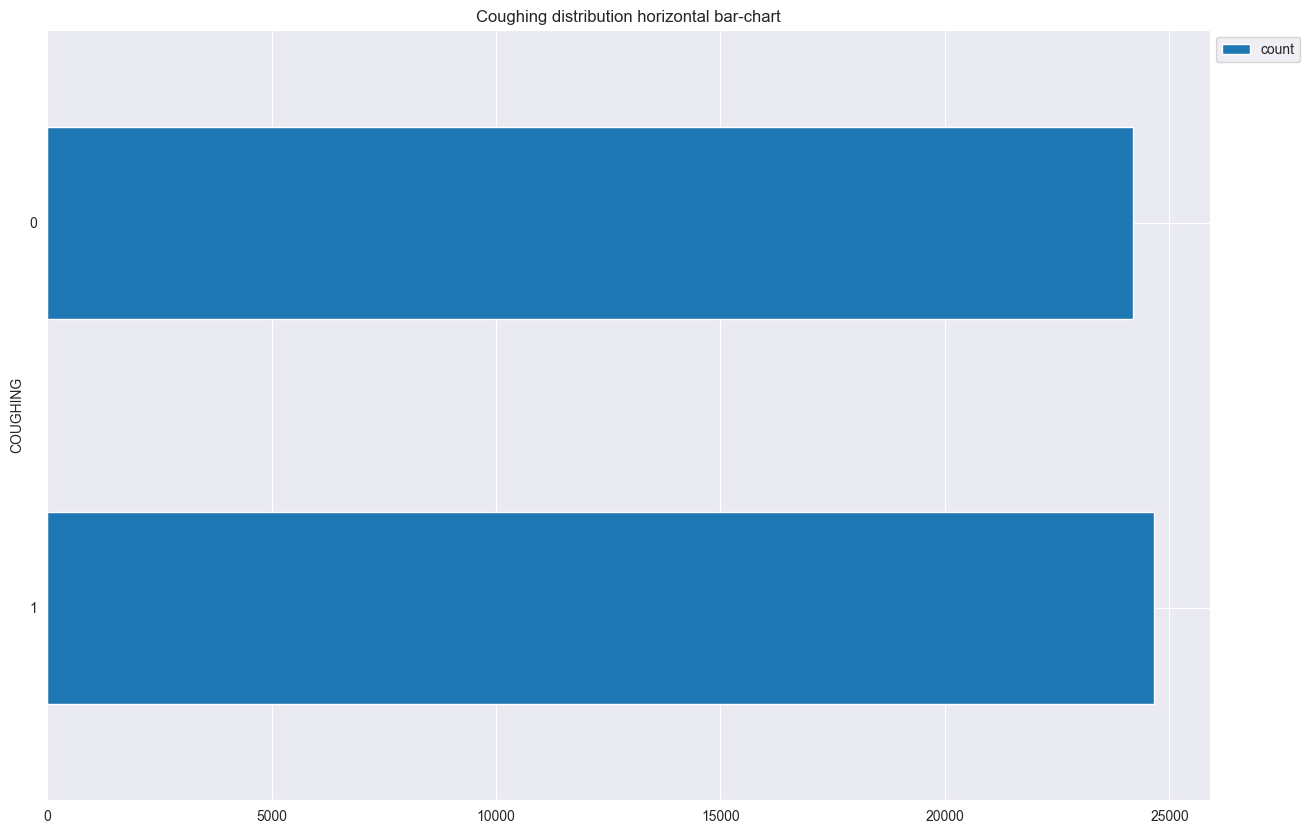

In [29]:
coughingPlot2 = df_unique['COUGHING'].value_counts().plot(kind = 'barh',title = "Coughing distribution horizontal bar-chart", figsize=(15,10))
coughingPlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

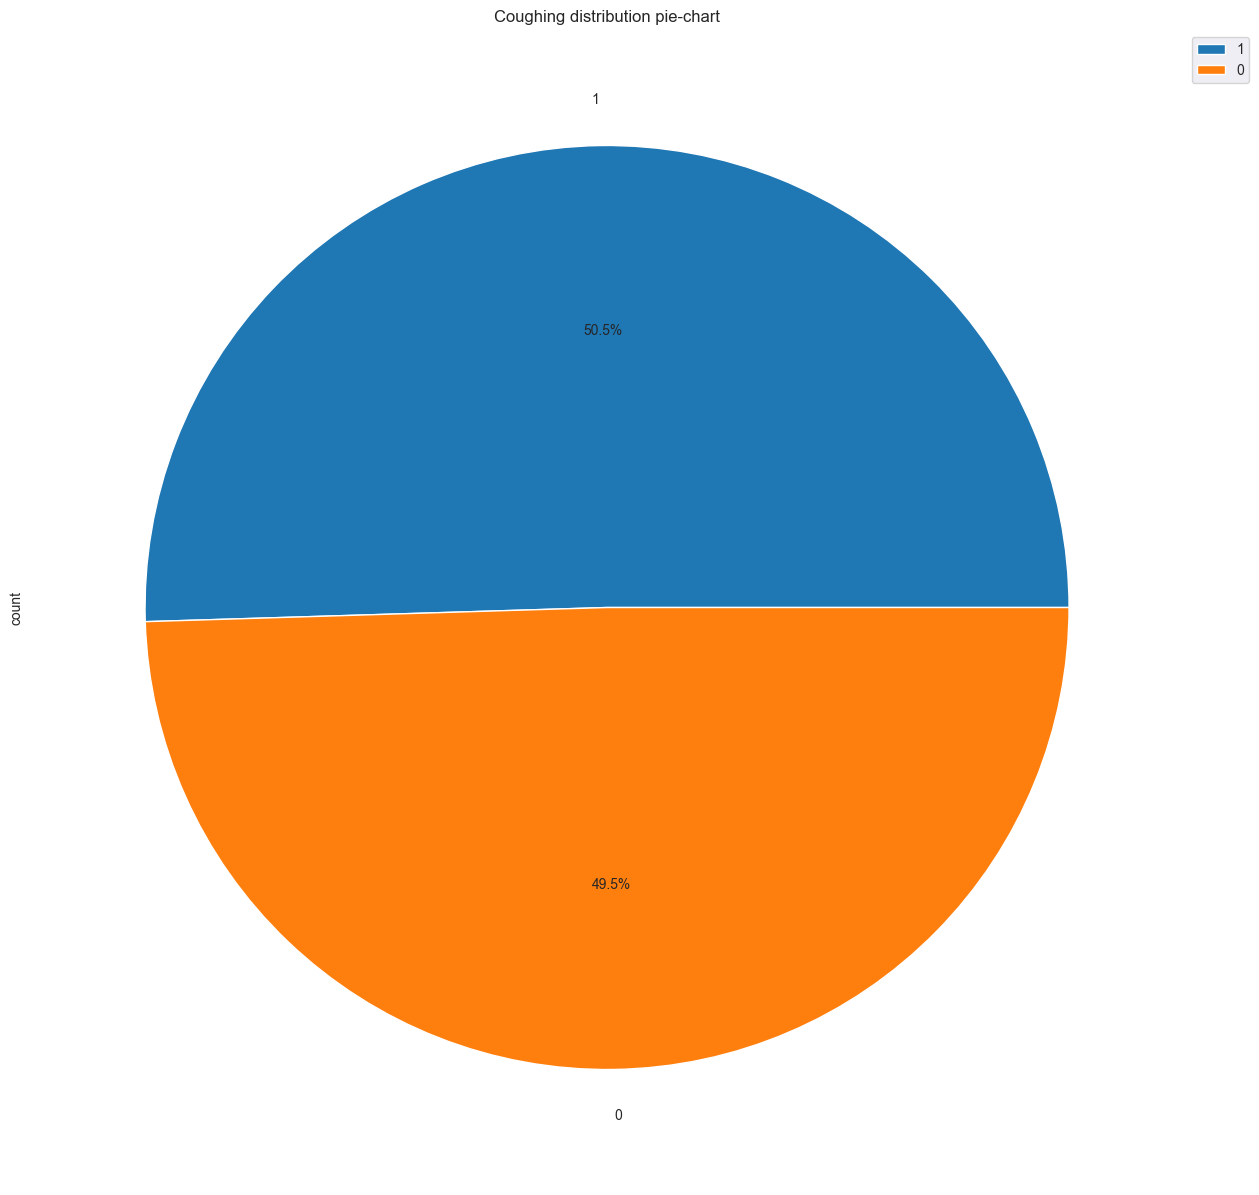

In [30]:
coughingPlot3 = df_unique['COUGHING'].value_counts().plot(kind = 'pie',title = "Coughing distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
coughingPlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

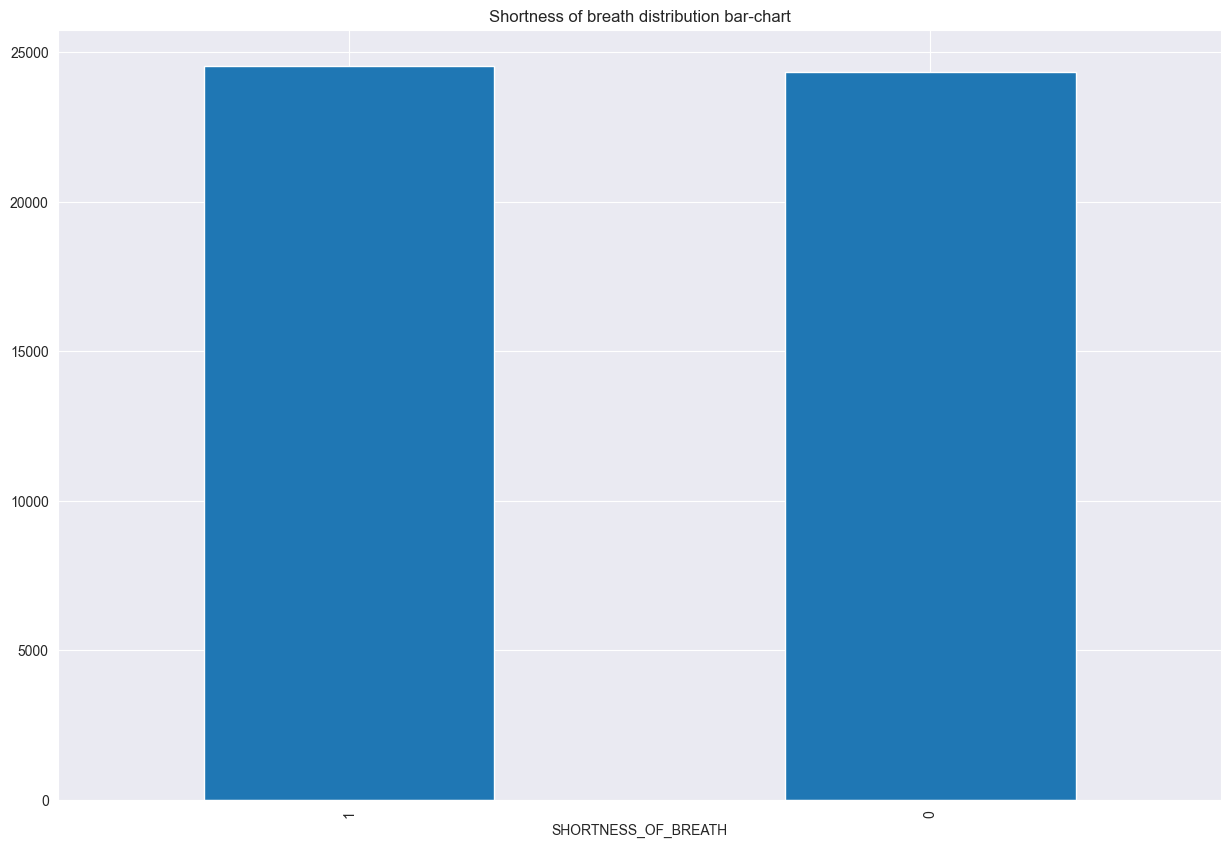

In [31]:
sOBreathPlot1 = df_unique['SHORTNESS_OF_BREATH'].value_counts().plot(kind = 'bar',title = "Shortness of breath distribution bar-chart", figsize=(15,10))
coughingPlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

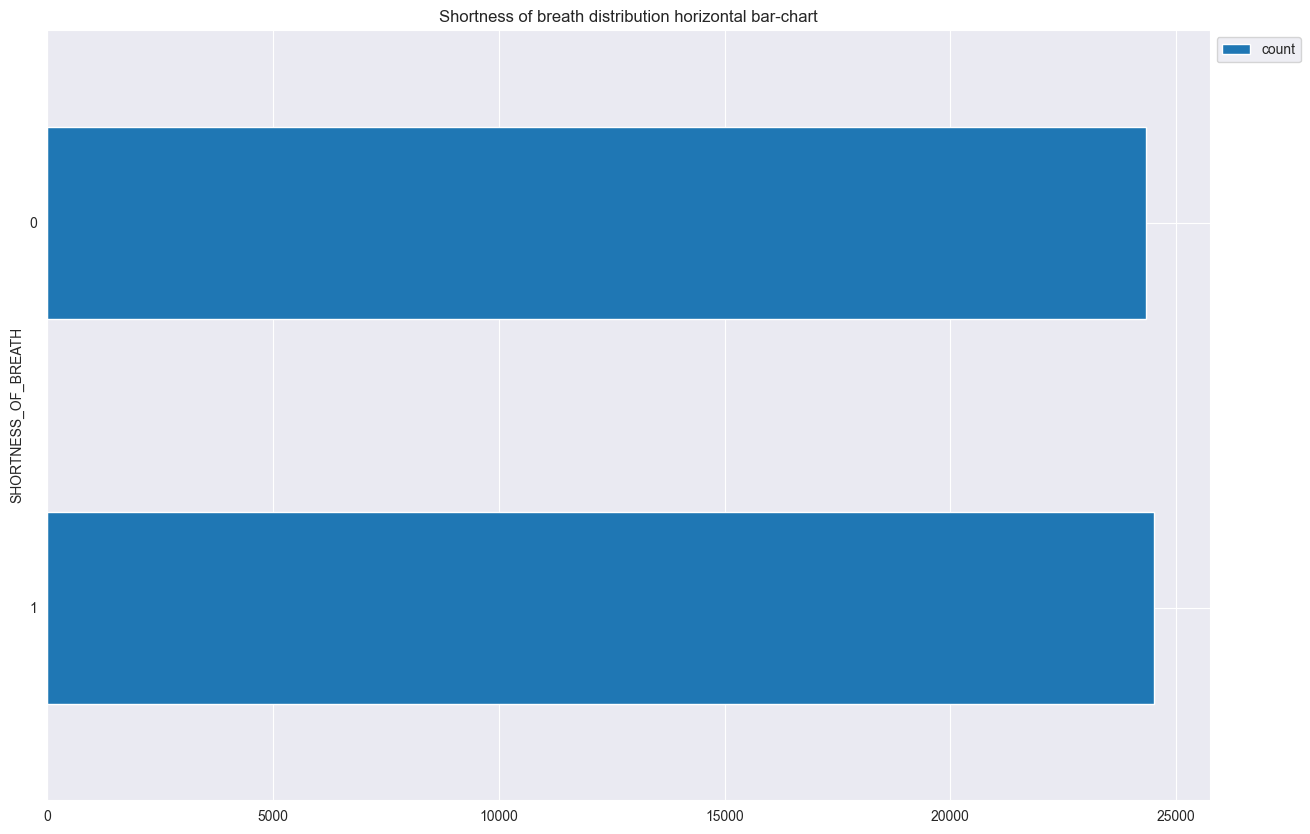

In [32]:
sOBreathPlot2 = df_unique['SHORTNESS_OF_BREATH'].value_counts().plot(kind = 'barh',title = "Shortness of breath distribution horizontal bar-chart", figsize=(15,10))
sOBreathPlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

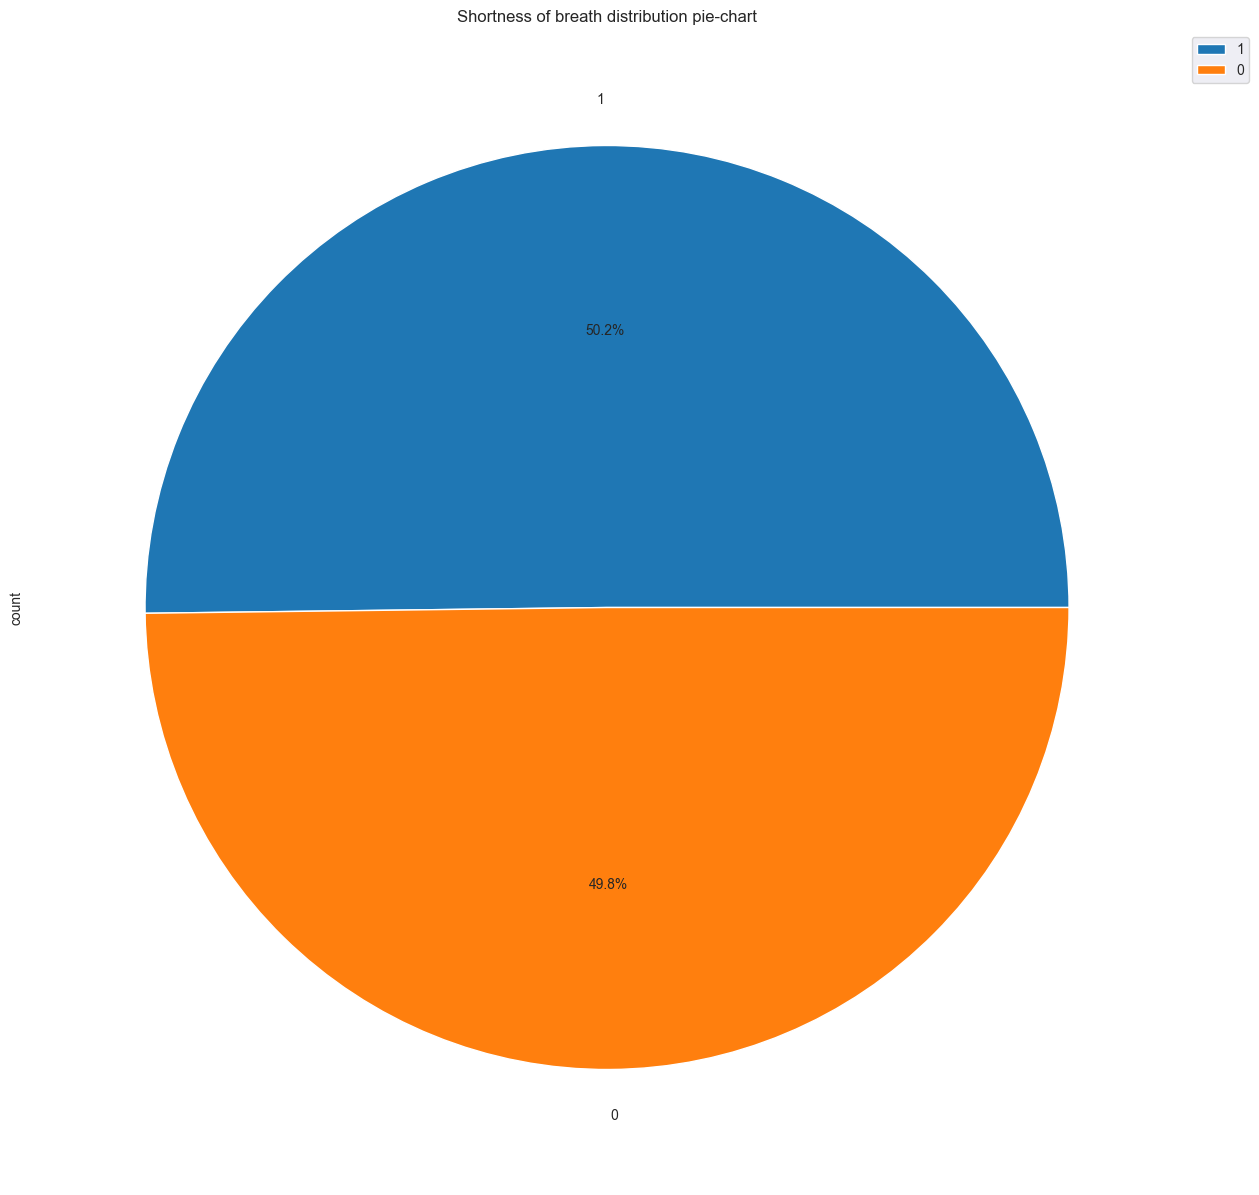

In [33]:
sOBreathPlot3 = df_unique['SHORTNESS_OF_BREATH'].value_counts().plot(kind = 'pie',title = "Shortness of breath distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
sOBreathPlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

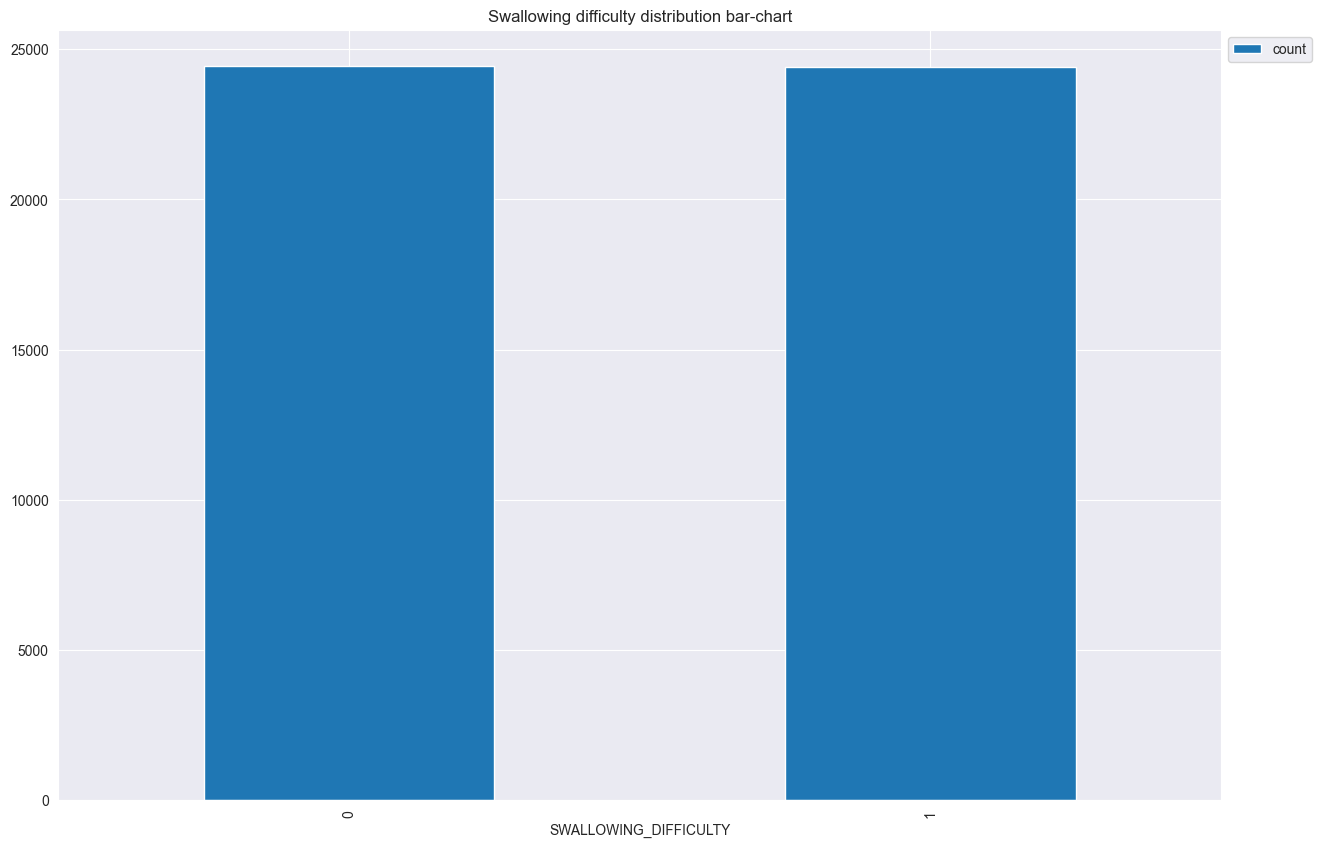

In [34]:
sDifficultyPlot1 = df_unique['SWALLOWING_DIFFICULTY'].value_counts().plot(kind = 'bar',title = "Swallowing difficulty distribution bar-chart", figsize=(15,10))
sDifficultyPlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

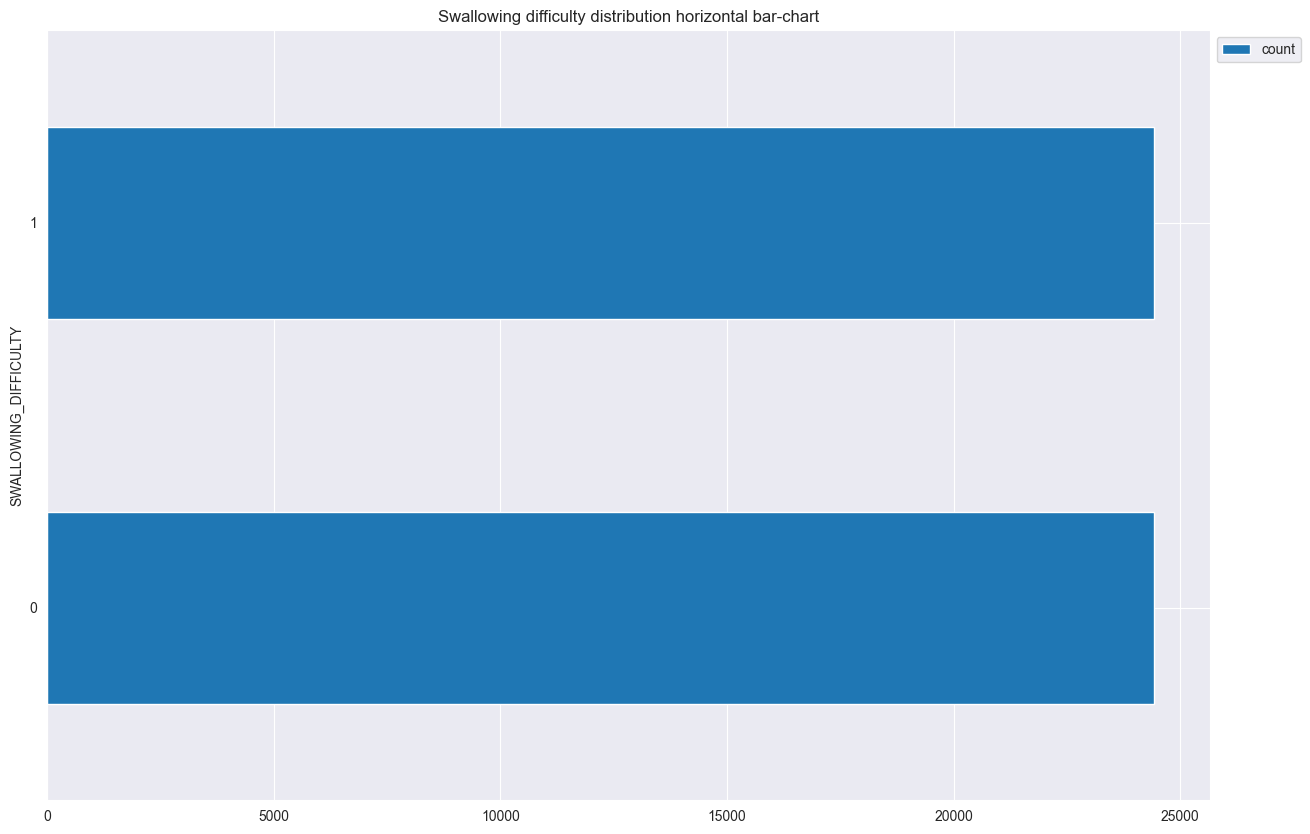

In [35]:
sDifficultyPlot2 = df_unique['SWALLOWING_DIFFICULTY'].value_counts().plot(kind = 'barh',title = "Swallowing difficulty distribution horizontal bar-chart", figsize=(15,10))
sDifficultyPlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

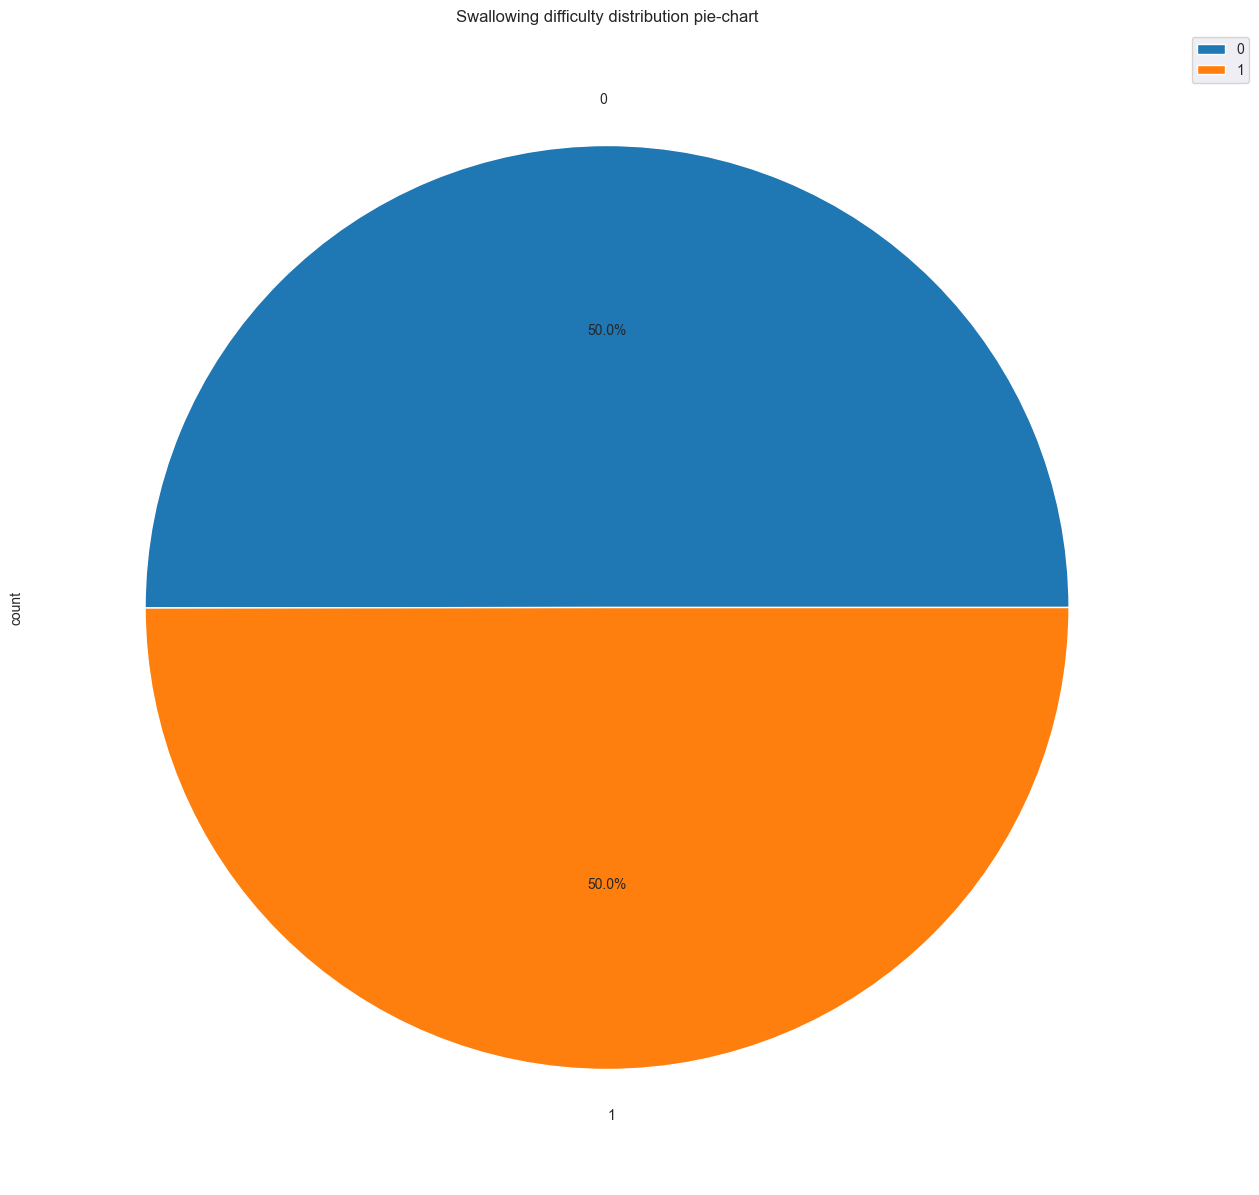

In [36]:
sDifficultyPlot3 = df_unique['SWALLOWING_DIFFICULTY'].value_counts().plot(kind = 'pie',title = "Swallowing difficulty distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
sDifficultyPlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

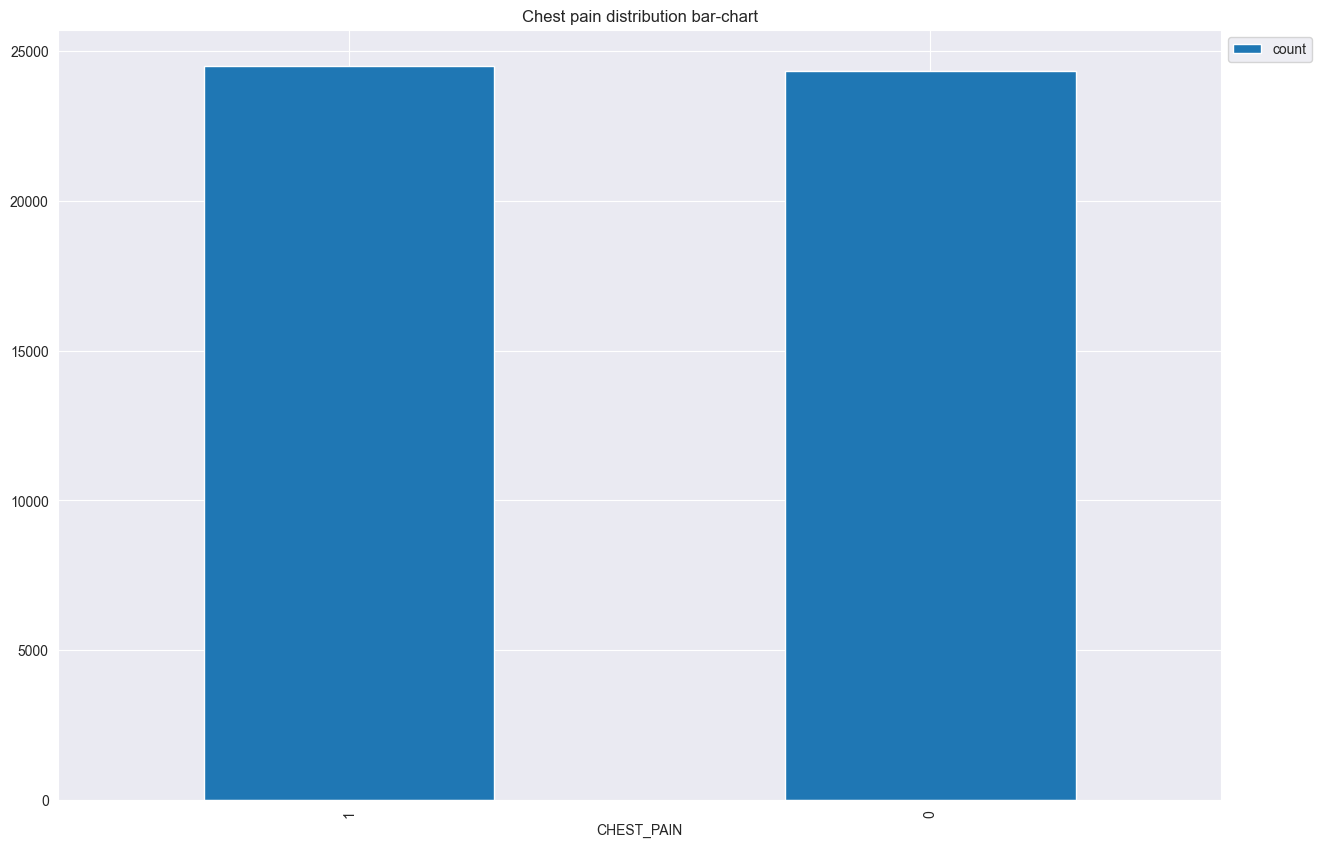

In [37]:
cPainPlot1 = df_unique['CHEST_PAIN'].value_counts().plot(kind = 'bar',title = "Chest pain distribution bar-chart", figsize=(15,10))
cPainPlot1.legend(loc='upper left', bbox_to_anchor=(1, 1))

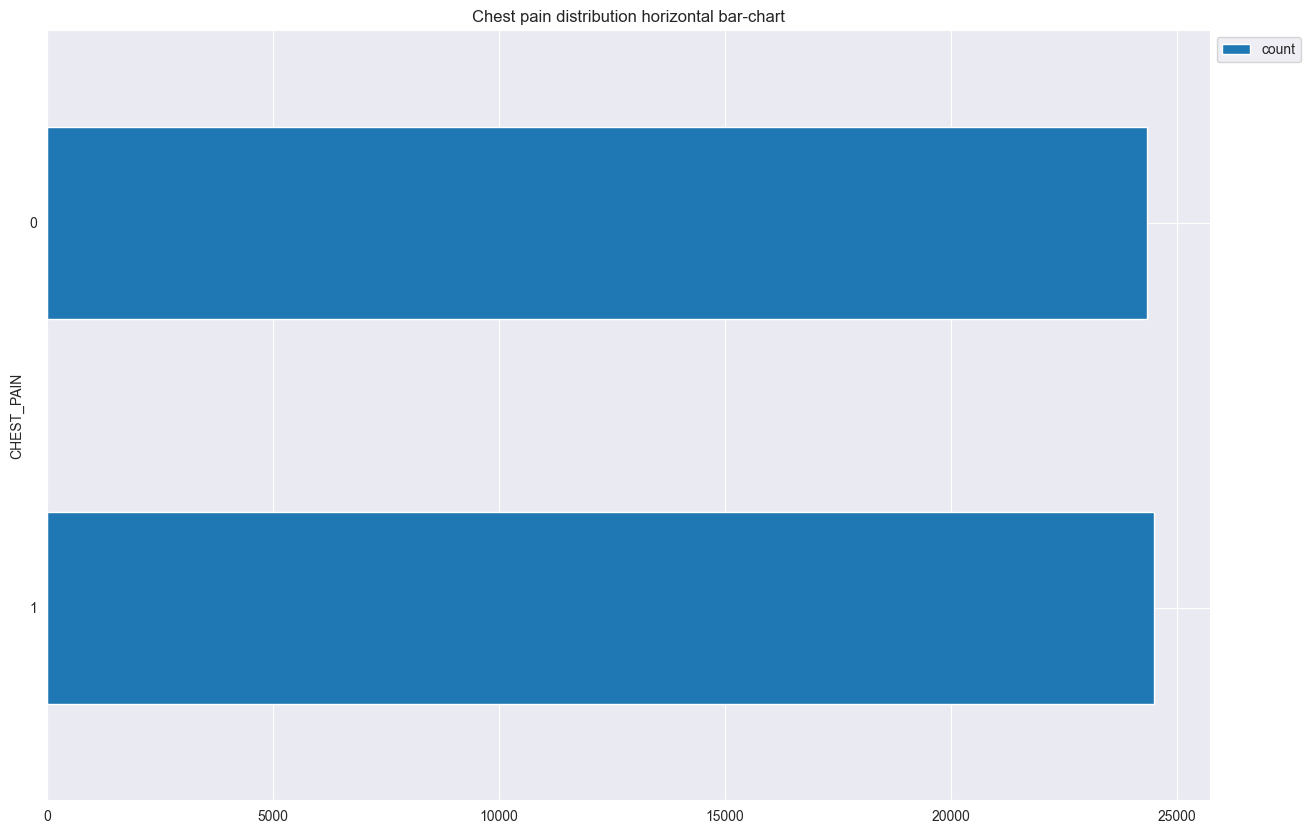

In [38]:
cPainPlot2 = df_unique['CHEST_PAIN'].value_counts().plot(kind = 'barh',title = "Chest pain distribution horizontal bar-chart", figsize=(15,10))
cPainPlot2.legend(loc='upper left', bbox_to_anchor=(1, 1))

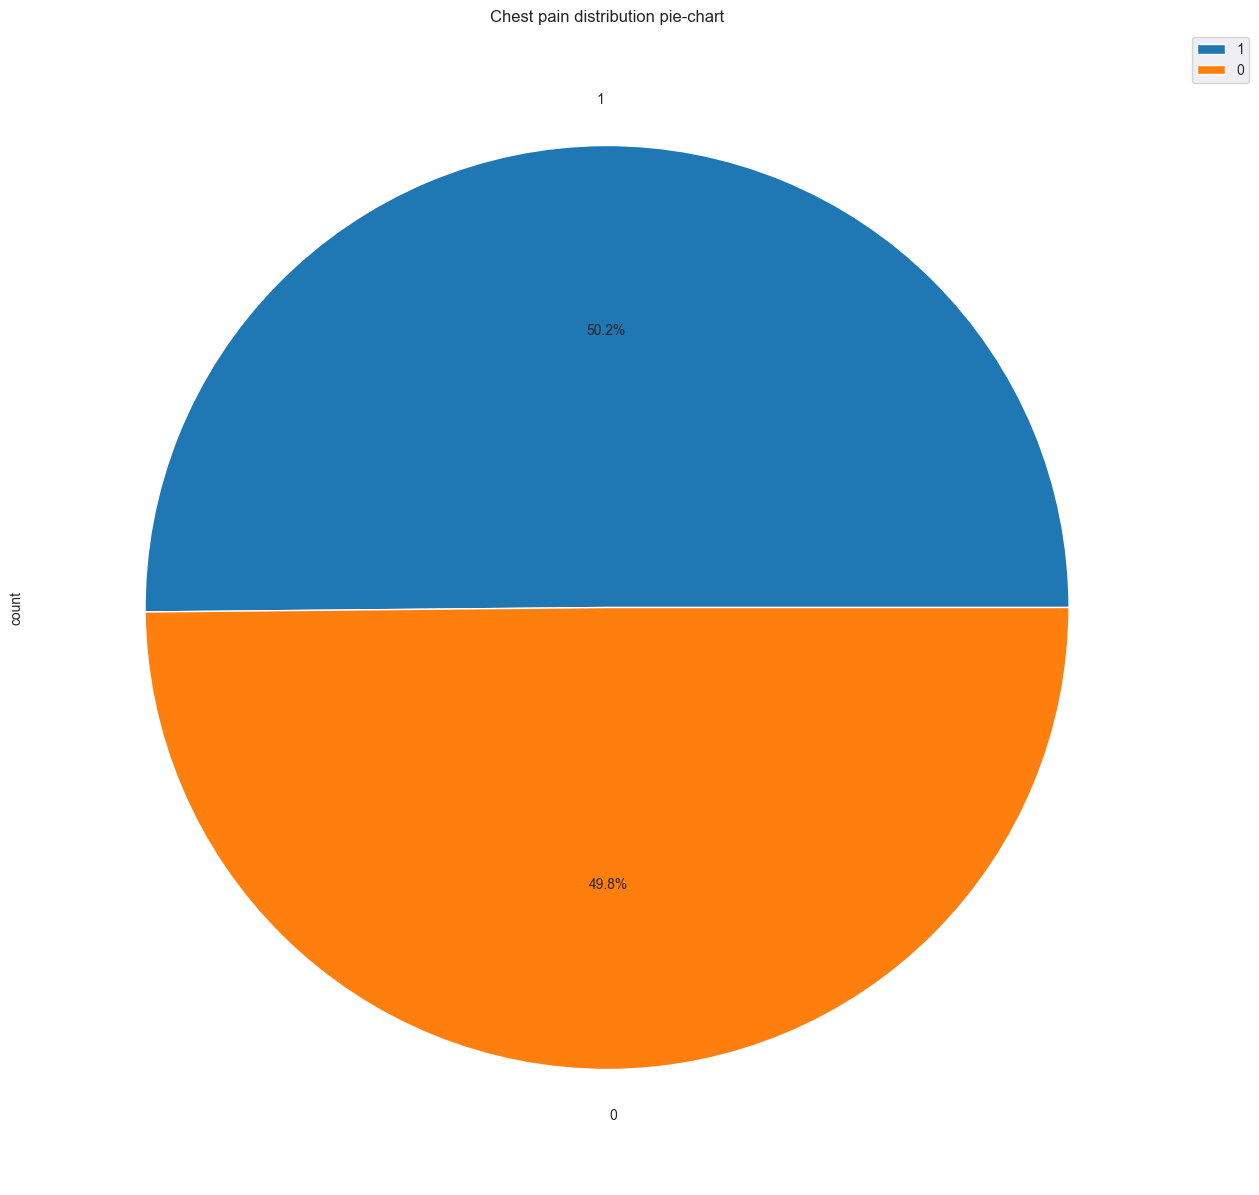

In [39]:
cPainPlot3 = df_unique['CHEST_PAIN'].value_counts().plot(kind = 'pie',title = "Chest pain distribution pie-chart", autopct='%1.1f%%', figsize=(15,15), legend = True)
cPainPlot3.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [40]:
y = df_unique["LUNG_CANCER"].copy()
X = df_unique.drop(columns=["LUNG_CANCER"])

# Identify numeric/categorical columns
# In your dataset: AGE is numeric; most others are categorical 1/2 (including GENDER)
numeric_cols = ["AGE"]
categorical_cols = [c for c in X.columns if c not in numeric_cols]

X_num = X[numeric_cols].astype(float).copy()
X_cat = X[categorical_cols].astype(str).copy()  # treat 1/2 as categories

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

X_mix = np.hstack([X_num_scaled, X_cat.to_numpy()])

cat_idx = list(range(X_num_scaled.shape[1], X_mix.shape[1]))  # categorical feature indices
cat_idx[:5], len(cat_idx)



([1, 2, 3, 4, 5], 11)

In [41]:
k = 2
kp = KPrototypes(n_clusters=k, init="Cao", n_init=5, verbose=1, random_state=42)

clusters = kp.fit_predict(X_mix, categorical=cat_idx)
df_unique["cluster"] = clusters
df_unique["cluster"].value_counts()

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 5386, ncost: 140763.02990874357
Run: 1, iteration: 2/100, moves: 1612, ncost: 140640.17171764164
Run: 1, iteration: 3/100, moves: 613, ncost: 140620.5407889094
Run: 1, iteration: 4/100, moves: 112, ncost: 140619.32908313806
Run: 1, iteration: 5/100, moves: 2, ncost: 140619.32821425487
Run: 1, iteration: 6/100, moves: 0, ncost: 140619.32821425487
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 4723, ncost: 140752.7201700365
Run: 2, iteration: 2/100, moves: 1546, ncost: 140638.73150790462
Run: 2, iteration: 3/100, moves: 601, ncost: 140620.2238664929
Run: 2, iteration: 4/100, moves: 95, ncost: 140619.329083138
Run: 2, iteration: 5/100, moves: 2, ncost: 140619.32821425443
Run: 2, iteration: 6/100, moves: 0, ncost: 140619.32821425443
Init: 

cluster
1    24462
0    24379
Name: count, dtype: int64

In [42]:
pd.crosstab(df_unique["cluster"], df_unique["LUNG_CANCER"], normalize="index")

LUNG_CANCER,0,1
cluster,,
0,0.502769,0.497231
1,0.504742,0.495258


In [43]:
categorical_cols = [c for c in X.columns if c != "AGE"]

# Proportion of "1" in each binary feature per cluster
rates = df_unique.groupby("cluster")[categorical_cols].mean()

# Absolute differences between clusters (cluster 1 - cluster 0)
diff = (rates.loc[1] - rates.loc[0]).sort_values(key=lambda s: s.abs(), ascending=False)

diff.head(10)

SWALLOWING_DIFFICULTY    0.099856
FATIGUE                  0.098550
COUGHING                -0.097169
SHORTNESS_OF_BREATH     -0.096954
SMOKING                  0.095847
ALLERGY                 -0.095522
CHEST_PAIN              -0.095479
GENDER                  -0.094988
YELLOW_FINGERS           0.091307
WHEEZING                -0.088067
dtype: float64

In [44]:
num_columns = df_unique.shape[1]
print(f"Number of columns: {num_columns}")

Number of columns: 14


In [45]:
print(df_unique.head(10))

   GENDER  AGE  SMOKING  YELLOW_FINGERS  CHRONIC_DISEASE  FATIGUE  ALLERGY  \
0       0   69        0               1                0        1        0   
1       0   74        1               0                1        1        1   
2       1   59        0               0                0        1        0   
3       0   63        1               1                0        0        0   
4       1   63        0               1                0        0        0   
5       1   75        0               1                1        1        1   
6       0   52        1               0                0        1        0   
7       1   51        1               1                0        1        1   
8       1   68        1               0                0        1        0   
9       0   53        1               1                1        0        1   

   WHEEZING  COUGHING  SHORTNESS_OF_BREATH  SWALLOWING_DIFFICULTY  CHEST_PAIN  \
0         1         1                    1                  

In [46]:
# Defining X (features) and y (target)
X = df_unique.drop(columns=["LUNG_CANCER", "cluster"])
y = df_unique["LUNG_CANCER"]

# Splitting dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

# Applying scalers to training and testing data
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Defining parameter grid for GridSearchCV
param_grid = {
    'n_neighbors': [5, 10, 15, 20, 25, 30],  # Trying different values for K
    'weights': ['uniform', 'distance'],      # Trying both weighting methods
    'metric': ['euclidean', 'manhattan']     # Trying different distance metrics
}

# Initializing KNN model
knn = KNeighborsClassifier()

# Applying GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters found
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

# Evaluating the best model
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
y_train_pred = best_knn.predict(X_train)

# Calculating accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)
error = 1 - test_accuracy

# Displaying results
print("KNN training accuracy:", train_accuracy)
print(f"KNN test error rate {error}")
print("KNN accuracy:", accuracy_score(y_test, y_pred))
print("KNN ROC-AUC:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'uniform'}
KNN training accuracy: 0.5826020826020826
KNN test error rate 0.5138879410359654
KNN accuracy: 0.48611205896403464
KNN ROC-AUC: 0.4849361712656687
              precision    recall  f1-score   support

           0       0.49      0.59      0.54      7406
           1       0.48      0.38      0.42      7247

    accuracy                           0.49     14653
   macro avg       0.48      0.48      0.48     14653
weighted avg       0.48      0.49      0.48     14653



In [47]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

# Best parameters
print("Random Forest Best Params:", grid_rf.best_params_)

# Best model
best_rf = grid_rf.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Accuracy: 0.4650242271207261
Random Forest ROC-AUC: 0.45174018761094614
              precision    recall  f1-score   support

           0       0.47      0.50      0.49      7406
           1       0.46      0.43      0.44      7247

    accuracy                           0.47     14653
   macro avg       0.46      0.46      0.46     14653
weighted avg       0.46      0.47      0.46     14653



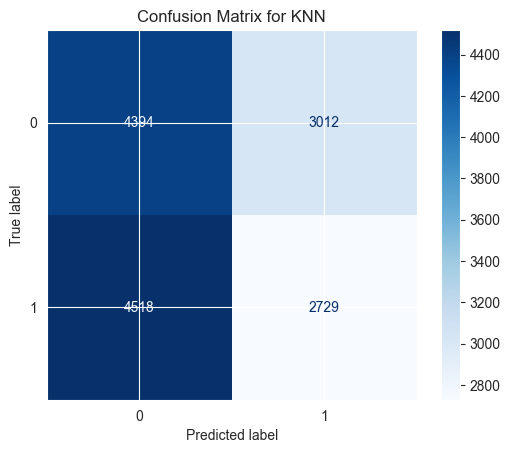

In [48]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for KNN")
plt.show()

In [49]:
feat_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_importance.head(10))

AGE                      0.440649
ALLERGY                  0.057452
FATIGUE                  0.056259
CHEST_PAIN               0.054816
YELLOW_FINGERS           0.054427
SHORTNESS_OF_BREATH      0.054030
SMOKING                  0.050593
SWALLOWING_DIFFICULTY    0.049892
GENDER                   0.049060
WHEEZING                 0.048198
dtype: float64


In [50]:
# Defining X (features) and y (target)
X1 = df_unique.drop(columns=["LUNG_CANCER", "cluster"])
y1 = df_unique["LUNG_CANCER"]

# Splitting dataset into training and testing data
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=7)

# Defining parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],  # Different splitting criteria
    'max_depth': [3, 5, 10, 15, None],  # Various tree depths
    'min_samples_split': [2, 5, 10]  # Minimum samples required to split a node
}

# Initializing Decision Tree model
clf = DecisionTreeClassifier()

# Applying GridSearchCV
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train1, y_train1)

# Best parameters found
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

# Evaluating the best model
best_clf = grid_search.best_estimator_
y_pred1 = best_clf.predict(X_test1)
y_train_pred1 = best_clf.predict(X_train1)

# Calculating accuracy
train_accuracy1 = accuracy_score(y_train1, y_train_pred1)
test_accuracy1 = accuracy_score(y_test1, y_pred1)
error1 = 1 - test_accuracy1

# Displaying results
print("Decision Tree training accuracy:", train_accuracy)
print(f"Decision Tree test error rate {error}")
print("Decision Tree accuracy:", accuracy_score(y_test1, y_pred1))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test1, y_pred1))
print(classification_report(y_test1, y_pred1))


Best Hyperparameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Decision Tree training accuracy: 0.5826020826020826
Decision Tree test error rate 0.5138879410359654
Decision Tree accuracy: 0.5020132396096363
Decision Tree ROC-AUC: 0.4977101068686975
              precision    recall  f1-score   support

           0       0.50      0.89      0.64      7406
           1       0.48      0.10      0.17      7247

    accuracy                           0.50     14653
   macro avg       0.49      0.50      0.41     14653
weighted avg       0.49      0.50      0.41     14653



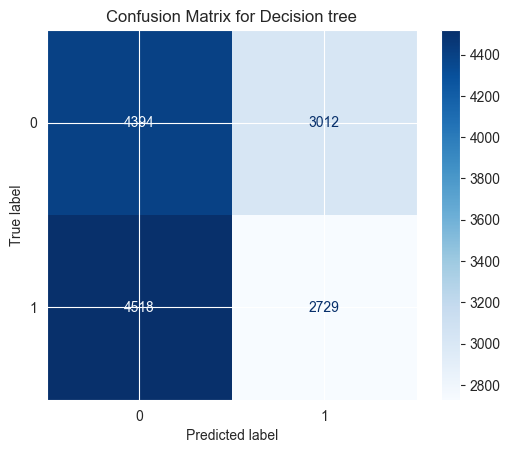

In [51]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Decision tree")
plt.show()

In [52]:
print("Overall y distribution:\n", y1.value_counts(normalize=True))
print("\nTrain y distribution:\n", y_train1.value_counts(normalize=True))
print("\nTest y distribution:\n", y_test1.value_counts(normalize=True))

Overall y distribution:
 LUNG_CANCER
0    0.503757
1    0.496243
Name: proportion, dtype: float64

Train y distribution:
 LUNG_CANCER
0    0.503042
1    0.496958
Name: proportion, dtype: float64

Test y distribution:
 LUNG_CANCER
0    0.505426
1    0.494574
Name: proportion, dtype: float64


In [53]:
# Defining X (features) and y (target)
X2 = df_unique.drop(columns=["LUNG_CANCER", "cluster"])
y2 = df_unique["LUNG_CANCER"]

#defining size of training and testing data
X_train2, X_test2, y_train2, y_test2 = model_selection.train_test_split(X2,y2,
test_size = 0.2, random_state = 4)

#applying scalers to training and testing data
scaler1 = MinMaxScaler()
scaler1.fit(X_train2)
X_train2 = scaler1.transform(X_train2)
X_test2 = scaler1.transform(X_test2)

lrn = LogisticRegression()    # fitting model to training data
lrn = lrn.fit(X_train2, y_train2)
lrn.get_params()

y_train_pred2 = lrn.predict(X_train2)
y_pred2 = lrn.predict(X_test2)   #predicting outcome and calculating accuracy
train_accuracy = metrics.accuracy_score(y_train2, y_train_pred2)
error = 1 - metrics.accuracy_score(y_test2, y_pred2)
print("Logistic Regression training accuracy:", train_accuracy)
print(f"Logistic Regression test error rate {error}")
print("Logistic Regression accuracy:", accuracy_score(y_test2, y_pred2))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

Logistic Regression training accuracy: 0.5068591318591319
Logistic Regression test error rate 0.4980038898556659
Logistic Regression accuracy: 0.5019961101443341
Logistic Regression ROC-AUC: 0.5000858809388755
              precision    recall  f1-score   support

           0       0.51      0.63      0.56      4959
           1       0.49      0.37      0.43      4810

    accuracy                           0.50      9769
   macro avg       0.50      0.50      0.49      9769
weighted avg       0.50      0.50      0.49      9769



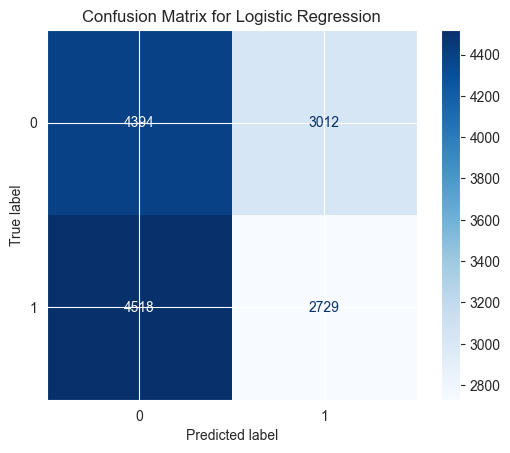

In [54]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

In [55]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("XGBoost Best Params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Best Params: {'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
XGBoost Accuracy: 0.5015355217361632
XGBoost ROC-AUC: 0.4940480646614702
[[5623 1783]
 [5521 1726]]
              precision    recall  f1-score   support

           0       0.50      0.76      0.61      7406
           1       0.49      0.24      0.32      7247

    accuracy                           0.50     14653
   macro avg       0.50      0.50      0.46     14653
weighted avg       0.50      0.50      0.47     14653



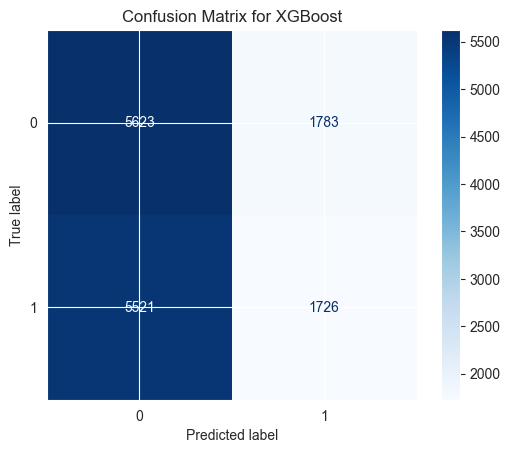

In [56]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for XGBoost")
plt.show()

In [57]:
param_grid_lgbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 10, 20]
}

lgbm = LGBMClassifier(random_state=42)

grid_lgbm = GridSearchCV(
    lgbm,
    param_grid_lgbm,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train)

print("LightGBM Best Params:", grid_lgbm.best_params_)

best_lgbm = grid_lgbm.best_estimator_

y_pred_lgbm = best_lgbm.predict(X_test)
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("LightGBM ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 16990, number of negative: 17198
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 81
[LightGBM] [Info] Number of data points in the train set: 34188, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.496958 -> initscore=-0.012168
[LightGBM] [Info] Start training from score -0.012168
LightGBM Best Params: {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 31}
LightGBM Accuracy: 0.49007029277281106
LightGBM ROC-AUC: 0.48152692719357815
[[4698 2708]
 [4764 2483]]
              precision    recall  f1-score   support

           0       0.50      0.63      0.56      7406
           1       0.48      0.34      0.40      7247

    accuracy                           0.49     14653
   macro avg       0

C:\Users\denis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\denis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


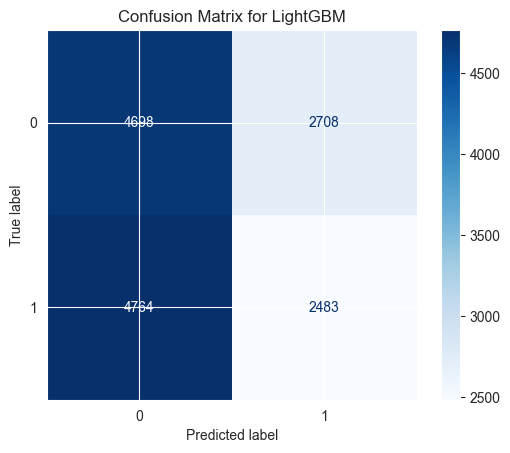

In [58]:
cm = confusion_matrix(y_test, y_pred_lgbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for LightGBM")
plt.show()